# Net2Brain 3D NN (NSD)

## extracting Data, RDM, and RSA

In [1]:
# CONFIGURATION
import os

from pathlib import Path

nsd_path = Path("../Algonauts23_shared_Net2Brain")

stimuli_path = nsd_path / "images"

print("NSD dataset:", nsd_path)
print("Stimuli path:", stimuli_path)
print("Images exist:", stimuli_path.exists())
print("Number of images:", len(list(stimuli_path.glob("*.png"))))

NSD dataset: ..\Algonauts23_shared_Net2Brain
Stimuli path: ..\Algonauts23_shared_Net2Brain\images
Images exist: True
Number of images: 872


In [2]:
# Paths for RSA

nsd_path = Path("../Algonauts23_shared_Net2Brain")

# All subjects
subject_paths = sorted(nsd_path.glob("subj*"))

# Brain RDM paths
subject_rdm_paths = {
    subject.name: subject / "rdms"
    for subject in subject_paths
}

print("NSD dataset:", nsd_path)

print("\nSubjects:")
for subject in subject_paths:
    print(subject.name)

print("\nRDM paths:")
for subject, rdm_path in subject_rdm_paths.items():
    print(subject, "->", rdm_path)

NSD dataset: ..\Algonauts23_shared_Net2Brain

Subjects:
subj01
subj02
subj03
subj04
subj05
subj06
subj07
subj08

RDM paths:
subj01 -> ..\Algonauts23_shared_Net2Brain\subj01\rdms
subj02 -> ..\Algonauts23_shared_Net2Brain\subj02\rdms
subj03 -> ..\Algonauts23_shared_Net2Brain\subj03\rdms
subj04 -> ..\Algonauts23_shared_Net2Brain\subj04\rdms
subj05 -> ..\Algonauts23_shared_Net2Brain\subj05\rdms
subj06 -> ..\Algonauts23_shared_Net2Brain\subj06\rdms
subj07 -> ..\Algonauts23_shared_Net2Brain\subj07\rdms
subj08 -> ..\Algonauts23_shared_Net2Brain\subj08\rdms


In [3]:
## create the two NSD RSA folders

import numpy as np
from pathlib import Path
from scipy.spatial.distance import squareform

nsd_path = Path("../Algonauts23_shared_Net2Brain")

# Output folders for RSA
nsd_visual_rdm_path = Path("NSD_visual_RDMs")
nsd_ppa_rdm_path = Path("NSD_PPA_RDMs")

nsd_visual_rdm_path.mkdir(exist_ok=True)
nsd_ppa_rdm_path.mkdir(exist_ok=True)

# ROIs for the visual cortex analysis
visual_rois = [
    "V1d",
    "V1v",
    "V2d",
    "V2v",
    "V3d",
    "V3v",
    "hV4"
]

# Function to combine the 8 subjects for ONE ROI + ONE hemisphere
def create_grouped_rdm(roi, hemisphere, output_folder):

    subject_rdms = []

    for subject_num in range(1, 9):

        file = (
            nsd_path
            / f"subj{subject_num:02d}"
            / "rdms"
            / f"{roi}_{hemisphere}_subj{subject_num:02d}.npy"
        )

        condensed_rdm = np.load(file)

        # 379756 values -> 872 x 872 RDM
        square_rdm = squareform(condensed_rdm)

        subject_rdms.append(square_rdm)

    # subjects × images × images
    subject_rdms = np.stack(subject_rdms)

    # Save in Net2Brain-compatible NPZ format
    output_file = output_folder / f"{roi}_{hemisphere}.npz"

    np.savez(
        output_file,
        rdm=subject_rdms
    )


# Create visual ROI RDMs
for roi in visual_rois:
    for hemisphere in ["lh", "rh"]:
        create_grouped_rdm(
            roi,
            hemisphere,
            nsd_visual_rdm_path
        )


# Create PPA RDMs
for hemisphere in ["lh", "rh"]:
    create_grouped_rdm(
        "PPA",
        hemisphere,
        nsd_ppa_rdm_path
    )


print("Visual RSA files:")
for file in sorted(nsd_visual_rdm_path.glob("*.npz")):
    print(file.name)

print("\nPPA RSA files:")
for file in sorted(nsd_ppa_rdm_path.glob("*.npz")):
    print(file.name)

Visual RSA files:
hV4_lh.npz
hV4_rh.npz
V1d_lh.npz
V1d_rh.npz
V1v_lh.npz
V1v_rh.npz
V2d_lh.npz
V2d_rh.npz
V2v_lh.npz
V2v_rh.npz
V3d_lh.npz
V3d_rh.npz
V3v_lh.npz
V3v_rh.npz

PPA RSA files:
PPA_lh.npz
PPA_rh.npz


### depth

In [4]:
from net2brain.feature_extraction import FeatureExtractor

fx_3d = FeatureExtractor(model='depth', 
                            netset='Taskonomy', 
                            device='cuda')



In [5]:
# Create features for the 3D model
fx_3d.extract(data_path=stimuli_path, 
                 save_path='Depth_feats_NSD_last2',
                 layers_to_extract=['layer3', 'layer4'])

Processing files:   0%|          | 0/872 [00:00<?, ?it/s]

Processing files: 100%|██████████| 872/872 [00:25<00:00, 33.62it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [00:05<00:00, 149.86it/s]


In [7]:
fx_3d.get_all_layers()

['',
 'conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1',
 'layer1.0',
 'layer1.0.conv1',
 'layer1.0.bn1',
 'layer1.0.conv2',
 'layer1.0.bn2',
 'layer1.0.conv3',
 'layer1.0.bn3',
 'layer1.0.relu',
 'layer1.0.downsample',
 'layer1.0.downsample.0',
 'layer1.0.downsample.1',
 'layer1.1',
 'layer1.1.conv1',
 'layer1.1.bn1',
 'layer1.1.conv2',
 'layer1.1.bn2',
 'layer1.1.conv3',
 'layer1.1.bn3',
 'layer1.1.relu',
 'layer1.2',
 'layer1.2.conv1',
 'layer1.2.bn1',
 'layer1.2.conv2',
 'layer1.2.bn2',
 'layer1.2.conv3',
 'layer1.2.bn3',
 'layer1.2.relu',
 'layer1.2.downsample',
 'layer1.2.downsample.0',
 'layer2',
 'layer2.0',
 'layer2.0.conv1',
 'layer2.0.bn1',
 'layer2.0.conv2',
 'layer2.0.bn2',
 'layer2.0.conv3',
 'layer2.0.bn3',
 'layer2.0.relu',
 'layer2.0.downsample',
 'layer2.0.downsample.0',
 'layer2.0.downsample.1',
 'layer2.1',
 'layer2.1.conv1',
 'layer2.1.bn1',
 'layer2.1.conv2',
 'layer2.1.bn2',
 'layer2.1.conv3',
 'layer2.1.bn3',
 'layer2.1.relu',
 'layer2.2',
 'layer2.2.conv1',
 'lay

#### RDM

In [8]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs 
creator_3d = RDMCreator(verbose=True, device='cuda')
creator_3d.create_rdms(feature_path="Depth_feats_NSD_last2", save_path="Depth_RDMs_NSD_last2", save_format='npz') 



c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('Depth_RDMs_NSD_last2')

Found: 2 RDM files
Depth_RDMs_NSD_last2\RDM_layer3.npz
Depth_RDMs_NSD_last2\RDM_layer4.npz
Class: RDM for layer layer3 with 6 stimuli


<Axes: title={'center': 'Layer=layer3'}>

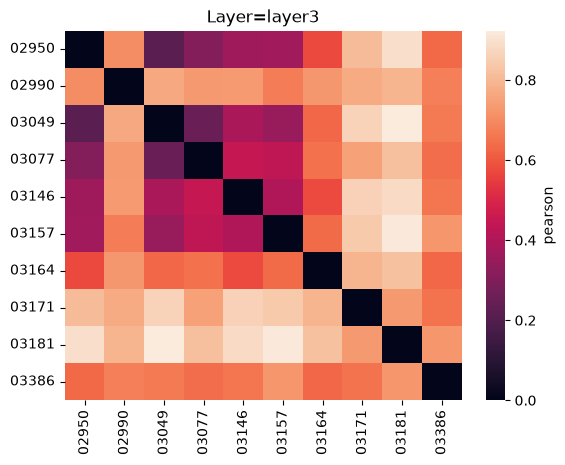

In [9]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Depth_RDMs_NSD_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files:
    print(f)


from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Depth_RDMs_NSD_last2/RDM_layer3.npz")         # Change the layer name to visualize different layers
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [ ]:
from net2brain.evaluations.rsa import RSA

model_rdms = "./Depth_RDMs_NSD_last2"

depth_visual_evaluation = RSA(
    model_rdms,
    "./NSD_visual_RDMs",
    model_name="Taskonomy Depth"
)

df_depth_visual = depth_visual_evaluation.evaluate()

display(df_depth_visual)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_layer3.npz,Taskonomy Depth,0.000309,0.311063,"[0.0004971316170612355, 0.00021643425389525106...",0.000087,0.000038,0.099376,0.262878
1,(0) hV4_lh,(1) RDM_layer4.npz,Taskonomy Depth,0.000115,0.115365,"[0.00018917826193065303, 4.4052529713193174e-0...",0.001880,0.000024,0.099376,0.262878
2,(1) hV4_rh,(0) RDM_layer3.npz,Taskonomy Depth,0.000310,0.311962,"[0.00060162090045975, 0.0001296860359915228, 0...",0.000526,0.000051,0.099353,0.262107
3,(1) hV4_rh,(1) RDM_layer4.npz,Taskonomy Depth,0.000081,0.081864,"[0.00015277502417284055, 2.3040959556956113e-0...",0.002400,0.000018,0.099353,0.262107
4,(2) V1d_lh,(0) RDM_layer3.npz,Taskonomy Depth,0.000392,0.222556,"[0.0006082448504861742, 0.0006560912324867654,...",0.001598,0.000079,0.176120,0.335863
5,(2) V1d_lh,(1) RDM_layer4.npz,Taskonomy Depth,0.000061,0.034418,"[0.00010199071610105003, 0.0001001030079754600...",0.004673,0.000015,0.176120,0.335863
6,(3) V1d_rh,(0) RDM_layer3.npz,Taskonomy Depth,0.000390,0.228396,"[0.0005874342722478396, 0.0003281278689551697,...",0.000189,0.000055,0.170802,0.331561
7,(3) V1d_rh,(1) RDM_layer4.npz,Taskonomy Depth,0.000070,0.041093,"[0.00011654364715940778, 4.329323745571118e-05...",0.005118,0.000017,0.170802,0.331561
8,(4) V1v_lh,(0) RDM_layer3.npz,Taskonomy Depth,0.001506,0.815869,"[0.0018558450451535476, 0.0007608338315098042,...",0.001930,0.000313,0.184608,0.344487
9,(4) V1v_lh,(1) RDM_layer4.npz,Taskonomy Depth,0.000954,0.517014,"[0.001000411209058039, 0.0002502256993646655, ...",0.005611,0.000242,0.184608,0.344487


In [11]:
depth_ppa_evaluation = RSA(
    "./Depth_RDMs_NSD_last2",
    "./NSD_PPA_RDMs",
    model_name="Taskonomy Depth"
)

df_depth_ppa = depth_ppa_evaluation.evaluate()

display(df_depth_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_layer3.npz,Taskonomy Depth,0.001411,0.830553,"[0.002204473695445542, 0.0013460643477802158, ...",0.002594,0.000309,0.169846,0.329043
1,(0) PPA_lh,(1) RDM_layer4.npz,Taskonomy Depth,0.000708,0.416754,"[0.0012568816930645982, 0.0006032718884899597,...",0.006444,0.000185,0.169846,0.329043
2,(1) PPA_rh,(0) RDM_layer3.npz,Taskonomy Depth,0.001470,0.767481,"[0.0025771161331218824, 0.002085098926967204, ...",0.000578,0.000248,0.191527,0.349057
3,(1) PPA_rh,(1) RDM_layer4.npz,Taskonomy Depth,0.000783,0.408624,"[0.001675227491014437, 0.0010994428069360026, ...",0.001764,0.000160,0.191527,0.349057


### Depth euclidean


In [12]:
from net2brain.feature_extraction import FeatureExtractor

fx_euc = FeatureExtractor(model='euclidean', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_euc.layers_to_extract)


['layer1', 'layer2', 'layer3', 'layer4']


In [13]:
# Create features for the 3D model
fx_euc.extract(data_path=stimuli_path, 
                 save_path='Euclidean_feats_NSD_last2',
                 layers_to_extract=['layer3', 'layer4'])

Processing files:   0%|          | 0/872 [00:00<?, ?it/s, subfiles=1/1]

Processing files: 100%|██████████| 872/872 [00:25<00:00, 33.74it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [00:06<00:00, 125.39it/s]


#### RDM

In [14]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs 
creator_euclidean = RDMCreator(verbose=True, device='cuda')
creator_euclidean.create_rdms(feature_path="Euclidean_feats_NSD_last2", save_path="Euclidean_RDMs_NSD_last2", save_format='npz', dim_reduction='scp') #

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('Euclidean_RDMs_NSD_last2')

Found: 2 RDM files
Euclidean_RDMs_NSD_last2\RDM_layer3.npz
Euclidean_RDMs_NSD_last2\RDM_layer4.npz
Class: RDM for layer layer3 with 6 stimuli


<Axes: title={'center': 'Layer=layer3'}>

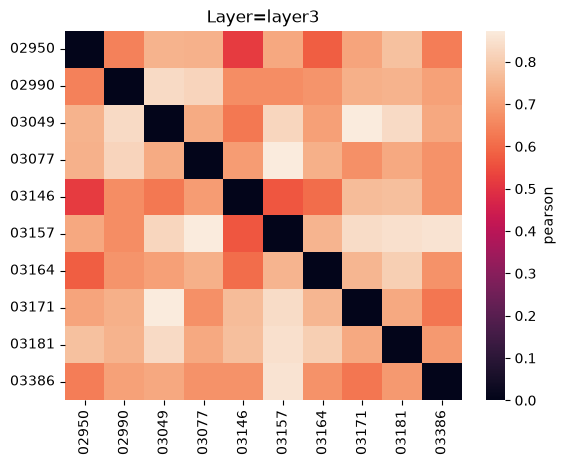

In [15]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Euclidean_RDMs_NSD_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)


from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Euclidean_RDMs_NSD_last2/RDM_layer3.npz")     # Change the layer name to visualize different layers
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [16]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./Euclidean_RDMs_NSD_last2"

# Start RSA
euclidean_visual_evaluation = RSA(model_rdms, 
                 "./NSD_visual_RDMs", 
                 model_name="Taskonomy Euclidean")

df_euc_visual = euclidean_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_euc_visual)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_layer3.npz,Taskonomy Euclidean,0.000527,0.530255,"[0.0008153892565480348, 0.0005556286338670935,...",4.280377e-05,0.000059,0.099376,0.262878
1,(0) hV4_lh,(1) RDM_layer4.npz,Taskonomy Euclidean,0.000536,0.539277,"[0.0007935433459222017, 0.0004911723962024724,...",4.160892e-05,0.000059,0.099376,0.262878
2,(1) hV4_rh,(0) RDM_layer3.npz,Taskonomy Euclidean,0.000630,0.633676,"[0.0008974980832426023, 0.0006990852069879649,...",1.558443e-04,0.000086,0.099353,0.262107
3,(1) hV4_rh,(1) RDM_layer4.npz,Taskonomy Euclidean,0.000646,0.649902,"[0.0010542894300740865, 0.0006866706731076248,...",1.951013e-04,0.000091,0.099353,0.262107
4,(2) V1d_lh,(0) RDM_layer3.npz,Taskonomy Euclidean,0.001036,0.588393,"[0.0015265975980410117, 0.0012890131173339577,...",1.169165e-04,0.000135,0.176120,0.335863
5,(2) V1d_lh,(1) RDM_layer4.npz,Taskonomy Euclidean,0.001144,0.649777,"[0.001447355098662054, 0.0014298539852466874, ...",6.551040e-06,0.000096,0.176120,0.335863
6,(3) V1d_rh,(0) RDM_layer3.npz,Taskonomy Euclidean,0.001128,0.660514,"[0.0013030266361495067, 0.0013869486181495349,...",2.049757e-05,0.000112,0.170802,0.331561
7,(3) V1d_rh,(1) RDM_layer4.npz,Taskonomy Euclidean,0.001115,0.652634,"[0.0012921443437636636, 0.0015703116992203327,...",1.975650e-05,0.000110,0.170802,0.331561
8,(4) V1v_lh,(0) RDM_layer3.npz,Taskonomy Euclidean,0.001446,0.783495,"[0.0019142405808030235, 0.0012881247033786549,...",1.168339e-05,0.000132,0.184608,0.344487
9,(4) V1v_lh,(1) RDM_layer4.npz,Taskonomy Euclidean,0.001440,0.779780,"[0.00175158279450295, 0.001483164922753561, 0....",8.423872e-07,0.000089,0.184608,0.344487


In [24]:
# against PPa

euc_ppa_evaluation = RSA(
    "./Euclidean_RDMs_NSD_last2",
    "./NSD_PPA_RDMs",
    model_name="Taskonomy Euclidean"
)

df_euc_ppa = euc_ppa_evaluation.evaluate()

display(df_euc_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_layer3.npz,Taskonomy Euclidean,0.001136,0.668748,"[0.0013642016789647278, 0.001322725197893689, ...",0.000312,0.000173,0.169846,0.329043
1,(0) PPA_lh,(1) RDM_layer4.npz,Taskonomy Euclidean,0.001519,0.894367,"[0.001356913140317537, 0.0017879583910449968, ...",0.000355,0.000236,0.169846,0.329043
2,(1) PPA_rh,(0) RDM_layer3.npz,Taskonomy Euclidean,0.001141,0.595816,"[0.0011779005748755325, 0.001383238372347388, ...",0.000140,0.000153,0.191527,0.349057
3,(1) PPA_rh,(1) RDM_layer4.npz,Taskonomy Euclidean,0.001568,0.818647,"[0.0012793212317216021, 0.0017570944459383137,...",0.000184,0.000219,0.191527,0.349057


### keypoints3d

In [18]:
from net2brain.feature_extraction import FeatureExtractor

fx_kp3d = FeatureExtractor(model='keypoints3d', 
                            netset='Taskonomy', 
                            device='cuda')


In [19]:
# Create features for the 3D model
fx_kp3d.extract(data_path=stimuli_path, 
                 save_path='KeyPoints3D_feats_NSD_last2',
                 layers_to_extract=['layer3', 'layer4'])

Processing files: 100%|██████████| 872/872 [00:28<00:00, 30.93it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [00:07<00:00, 112.43it/s]


#### RDM

In [20]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs
creator_keypoints3d = RDMCreator(verbose=True, device='cuda')
creator_keypoints3d.create_rdms(feature_path="KeyPoints3D_feats_NSD_last2", save_path="KeyPoints3D_RDMs_NSD_last2", save_format='npz') 

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('KeyPoints3D_RDMs_NSD_last2')

Found: 2 RDM files
Keypoints3D_RDMs_NSD_last2\RDM_layer3.npz
Keypoints3D_RDMs_NSD_last2\RDM_layer4.npz
Class: RDM for layer layer3 with 6 stimuli


<Axes: title={'center': 'Layer=layer3'}>

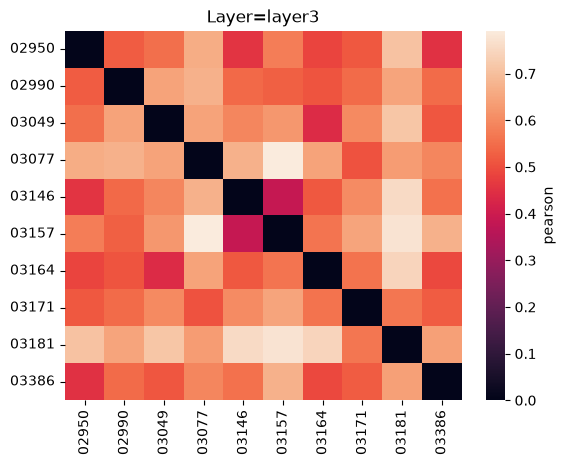

In [21]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Keypoints3D_RDMs_NSD_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)

from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Keypoints3D_RDMs_NSD_last2/RDM_layer3.npz")
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [22]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./KeyPoints3D_RDMs_NSD_last2"

# Start RSA
keypoints3d_visual_evaluation = RSA(model_rdms, 
                 "./NSD_visual_RDMs", 
                 model_name="Taskonomy KeyPoints3D")

df_kp3d_visual = keypoints3d_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_kp3d_visual)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000177,0.178536,"[0.00026711021904562716, 0.0003664180089027015...",0.001441,0.000035,0.099376,0.262878
1,(0) hV4_lh,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000235,0.236248,"[0.0003501031114827497, 0.00044089542309085886...",0.000588,0.000040,0.099376,0.262878
2,(1) hV4_rh,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000301,0.302741,"[0.00028752122739520325, 0.0003829698690422663...",0.001469,0.000059,0.099353,0.262107
3,(1) hV4_rh,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000373,0.375663,"[0.0004407951008204624, 0.0004909619817383161,...",0.000659,0.000064,0.099353,0.262107
4,(2) V1d_lh,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000563,0.319861,"[0.0007715549035300048, 0.0005801771145704697,...",0.000756,0.000099,0.176120,0.335863
5,(2) V1d_lh,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000768,0.436294,"[0.0011062944470315603, 0.0008874780956696174,...",0.000201,0.000109,0.176120,0.335863
6,(3) V1d_rh,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000553,0.323761,"[0.0005967988808104294, 0.0007119216803149153,...",0.000057,0.000064,0.170802,0.331561
7,(3) V1d_rh,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000661,0.387116,"[0.0008650852507907246, 0.0009079002942341056,...",0.000085,0.000082,0.170802,0.331561
8,(4) V1v_lh,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000370,0.200252,"[0.0005832824412295881, 0.0005603909932554061,...",0.000287,0.000055,0.184608,0.344487
9,(4) V1v_lh,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000506,0.274049,"[0.0007770299320260897, 0.0008195452627817074,...",0.000365,0.000079,0.184608,0.344487


In [23]:
# against PPa

keypoints3d_ppa_evaluation = RSA(
    "./KeyPoints3D_RDMs_NSD_last2",
    "./NSD_PPA_RDMs",
    model_name="Taskonomy KeyPoints3D"
)

df_kp3d_ppa = keypoints3d_ppa_evaluation.evaluate()

display(df_kp3d_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000353,0.207651,"[0.0003088214798169279, 0.00044717769411077395...",0.001208,0.000067,0.169846,0.329043
1,(0) PPA_lh,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000515,0.303333,"[0.0005254909870523934, 0.0007200926972205224,...",0.001258,0.000099,0.169846,0.329043
2,(1) PPA_rh,(0) RDM_layer3.npz,Taskonomy KeyPoints3D,0.000391,0.204403,"[0.00013516184445143894, 0.0003044210076123755...",0.002218,0.000083,0.191527,0.349057
3,(1) PPA_rh,(1) RDM_layer4.npz,Taskonomy KeyPoints3D,0.000535,0.279117,"[0.00032689894850278364, 0.0004568607330482889...",0.000985,0.000099,0.191527,0.349057


### normal

In [25]:
from net2brain.feature_extraction import FeatureExtractor

fx_normal = FeatureExtractor(model='normal', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_normal.layers_to_extract)


['layer1', 'layer2', 'layer3', 'layer4']


In [26]:
# Create features for the 3D model
fx_normal.extract(data_path=stimuli_path, 
                  save_path='Normal_feats_NSD_last2',
                  layers_to_extract=['layer3', 'layer4'])

Processing files: 100%|██████████| 872/872 [00:27<00:00, 31.22it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [00:06<00:00, 132.20it/s]


#### RDM

In [27]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs for the Scene Classification model
creator_normal = RDMCreator(verbose=True, device='cuda')
creator_normal.create_rdms(feature_path="Normal_feats_NSD_last2", save_path="Normal_RDMs_NSD_last2", save_format='npz') 

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('Normal_RDMs_NSD_last2')

Found: 2 RDM files
Normal_RDMs_NSD_last2\RDM_layer3.npz
Normal_RDMs_NSD_last2\RDM_layer4.npz
Class: RDM for layer layer4 with 6 stimuli


<Axes: title={'center': 'Layer=layer4'}>

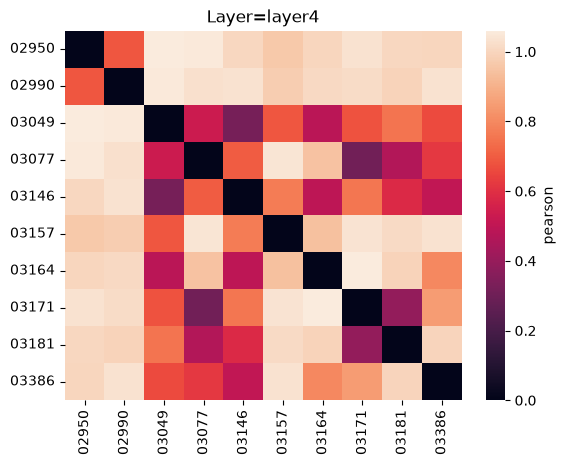

In [28]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Normal_RDMs_NSD_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)

from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Normal_RDMs_NSD_last2/RDM_layer4.npz")
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [29]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./Normal_RDMs_NSD_last2"

# Start RSA
normal_visual_evaluation = RSA(model_rdms, 
                 "./NSD_visual_RDMs", 
                 model_name="Taskonomy Normal")

df_normal_visual = normal_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_normal_visual)


,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_layer3.npz,Taskonomy Normal,0.000311,0.312928,"[0.0004338068064785453, 0.00024896549424223636...",0.000718,0.000054,0.099376,0.262878
1,(0) hV4_lh,(1) RDM_layer4.npz,Taskonomy Normal,0.000164,0.165319,"[0.0001966934912644844, 0.00010969105354300817...",0.003475,0.000038,0.099376,0.262878
2,(1) hV4_rh,(0) RDM_layer3.npz,Taskonomy Normal,0.000355,0.357081,"[0.0005404433728461667, 0.00026551088413557573...",0.000662,0.000061,0.099353,0.262107
3,(1) hV4_rh,(1) RDM_layer4.npz,Taskonomy Normal,0.000201,0.202573,"[0.00030081005529580167, 0.0002024698821826639...",0.005099,0.000050,0.099353,0.262107
4,(2) V1d_lh,(0) RDM_layer3.npz,Taskonomy Normal,0.000724,0.410888,"[0.0012013618342513882, 0.0007402800210578445,...",0.001927,0.000150,0.176120,0.335863
5,(2) V1d_lh,(1) RDM_layer4.npz,Taskonomy Normal,0.000331,0.187749,"[0.0005334388791413061, 0.00020742615968944177...",0.002522,0.000072,0.176120,0.335863
6,(3) V1d_rh,(0) RDM_layer3.npz,Taskonomy Normal,0.000770,0.450968,"[0.0010846222934066752, 0.0005886074450528318,...",0.000095,0.000097,0.170802,0.331561
7,(3) V1d_rh,(1) RDM_layer4.npz,Taskonomy Normal,0.000334,0.195306,"[0.00043073928310492424, 0.0001696717819211169...",0.000242,0.000049,0.170802,0.331561
8,(4) V1v_lh,(0) RDM_layer3.npz,Taskonomy Normal,0.002080,1.126685,"[0.002863973554185373, 0.001048671031047471, 0...",0.000240,0.000303,0.184608,0.344487
9,(4) V1v_lh,(1) RDM_layer4.npz,Taskonomy Normal,0.001880,1.018166,"[0.002457418193288425, 0.0006787602852131913, ...",0.000399,0.000298,0.184608,0.344487


In [30]:
# against PPa

normal_ppa_evaluation = RSA(
    "./Normal_RDMs_NSD_last2",
   "./NSD_PPA_RDMs",
    model_name="Taskonomy Normal"
)

df_normal_ppa = normal_ppa_evaluation.evaluate()

display(df_normal_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_layer3.npz,Taskonomy Normal,0.001152,0.678199,"[0.0009621733681683683, 0.0014378859646007331,...",0.000232,0.000167,0.169846,0.329043
1,(0) PPA_lh,(1) RDM_layer4.npz,Taskonomy Normal,0.000493,0.290377,"[0.00032487791064601785, 0.0007015706543163845...",0.000453,0.000080,0.169846,0.329043
2,(1) PPA_rh,(0) RDM_layer3.npz,Taskonomy Normal,0.001364,0.712296,"[0.0014183802565954139, 0.0019095683509711562,...",0.000158,0.000186,0.191527,0.349057
3,(1) PPA_rh,(1) RDM_layer4.npz,Taskonomy Normal,0.000670,0.349948,"[0.0006707338058279126, 0.0009396327374496589,...",0.000362,0.000104,0.191527,0.349057


### Curvature

In [31]:
from net2brain.feature_extraction import FeatureExtractor

fx_curvature = FeatureExtractor(model='curvature', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_curvature.layers_to_extract)

['layer1', 'layer2', 'layer3', 'layer4']


In [32]:
# Create features for the 3D model
fx_curvature.extract(data_path=stimuli_path, 
                  save_path='Curvature_feats_NSD_last2',
                  layers_to_extract=[ 'layer3', 'layer4'])

Processing files: 100%|██████████| 872/872 [00:26<00:00, 33.28it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [00:07<00:00, 118.18it/s]


#### RDM

In [33]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs for the Scene Classification model
creator_curvature = RDMCreator(verbose=True, device='cuda')
creator_curvature.create_rdms(feature_path="Curvature_feats_NSD_last2", save_path="Curvature_RDMs_NSD_last2", save_format='npz') 

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('Curvature_RDMs_NSD_last2')

Found: 2 RDM files
Curvature_RDMs_NSD_last2\RDM_layer3.npz
Curvature_RDMs_NSD_last2\RDM_layer4.npz
Class: RDM for layer layer4 with 6 stimuli


<Axes: title={'center': 'Layer=layer4'}>

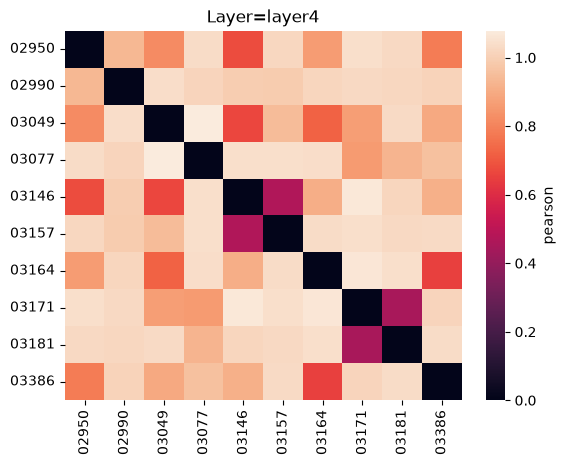

In [34]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("Curvature_RDMs_NSD_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)

from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("Curvature_RDMs_NSD_last2/RDM_layer4.npz")
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [35]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./Curvature_RDMs_NSD_last2"

# Start RSA
curvature_visual_evaluation = RSA(model_rdms, 
                 "./NSD_visual_RDMs", 
                 model_name="Taskonomy Curvature")

df_curvature_visual = curvature_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_curvature_visual)



,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_layer3.npz,Taskonomy Curvature,0.000035,0.035017,"[8.089422616678376e-05, 2.915119620876441e-05,...",0.004067,0.000008,0.099376,0.262878
1,(0) hV4_lh,(1) RDM_layer4.npz,Taskonomy Curvature,0.000050,0.050469,"[0.00011058785290211045, 5.898279400851539e-05...",0.004584,0.000012,0.099376,0.262878
2,(1) hV4_rh,(0) RDM_layer3.npz,Taskonomy Curvature,0.000063,0.063813,"[0.00010915072967670262, 5.0888863749406e-05, ...",0.014793,0.000020,0.099353,0.262107
3,(1) hV4_rh,(1) RDM_layer4.npz,Taskonomy Curvature,0.000081,0.081069,"[0.00023615876836329932, 0.0001576746171538654...",0.026569,0.000029,0.099353,0.262107
4,(2) V1d_lh,(0) RDM_layer3.npz,Taskonomy Curvature,0.000180,0.102360,"[0.0004712606454070636, 0.000162317477138007, ...",0.017081,0.000058,0.176120,0.335863
5,(2) V1d_lh,(1) RDM_layer4.npz,Taskonomy Curvature,0.000180,0.102021,"[0.000515120461501194, 9.785660135492383e-05, ...",0.027207,0.000065,0.176120,0.335863
6,(3) V1d_rh,(0) RDM_layer3.npz,Taskonomy Curvature,0.000318,0.186269,"[0.0004826333313265696, 0.00032704216170916347...",0.000170,0.000044,0.170802,0.331561
7,(3) V1d_rh,(1) RDM_layer4.npz,Taskonomy Curvature,0.000265,0.155243,"[0.00039293999043775907, 0.0002097850677913903...",0.000311,0.000040,0.170802,0.331561
8,(4) V1v_lh,(0) RDM_layer3.npz,Taskonomy Curvature,0.000403,0.218285,"[0.0008905341114527301, 0.00019582024379960822...",0.002781,0.000089,0.184608,0.344487
9,(4) V1v_lh,(1) RDM_layer4.npz,Taskonomy Curvature,0.000695,0.376274,"[0.00146497821399961, 0.000279620914169863, 0....",0.003201,0.000158,0.184608,0.344487


In [36]:
# against PPa

curvature_ppa_evaluation = RSA(
    "./Curvature_RDMs_NSD_last2",
   "./NSD_PPA_RDMs",
    model_name="Taskonomy Curvature"
)

df_curvature_ppa = curvature_ppa_evaluation.evaluate()

display(df_curvature_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_layer3.npz,Taskonomy Curvature,0.000176,0.103767,"[0.00011348176119729394, 0.0002149371077807907...",0.000487,0.000029,0.169846,0.329043
1,(0) PPA_lh,(1) RDM_layer4.npz,Taskonomy Curvature,0.000112,0.066221,"[0.00010016111348567724, 0.0001090186009743984...",0.001205,0.000021,0.169846,0.329043
2,(1) PPA_rh,(0) RDM_layer3.npz,Taskonomy Curvature,0.000199,0.103825,"[0.00010611243415882116, 0.0002048395310181314...",0.000315,0.000030,0.191527,0.349057
3,(1) PPA_rh,(1) RDM_layer4.npz,Taskonomy Curvature,0.000113,0.058966,"[8.495184647334745e-05, 0.00011124611276744948...",0.000403,0.000018,0.191527,0.349057


### Room_layout

In [37]:
from net2brain.feature_extraction import FeatureExtractor

fx_roomLayout = FeatureExtractor(model='room_layout', 
                            netset='Taskonomy', 
                            device='cuda')

print(fx_roomLayout.layers_to_extract)


['layer1', 'layer2', 'layer3', 'layer4']


In [38]:
# Create features for the 3D model
fx_roomLayout.extract(data_path=stimuli_path, 
                  save_path='RoomLayout_feats_NSD_last2',
                  layers_to_extract=['layer3', 'layer4'])

Processing files: 100%|██████████| 872/872 [00:27<00:00, 31.70it/s, subfiles=1/1]


Consolidating data per layer...


100%|██████████| 872/872 [00:08<00:00, 99.67it/s] 


#### RDM

In [39]:
from net2brain.rdm_creation import RDMCreator

# Create RDMs for the Scene Classification model
creator_roomLayout = RDMCreator(verbose=True, device='cuda')
creator_roomLayout.create_rdms(feature_path="RoomLayout_feats_NSD_last2", save_path="RoomLayout_RDMs_NSD_last2", save_format='npz') 

c:\Users\tinke\Documents\constructor university (undergraduate)\net2brain\research\.venv\Lib\site-packages\net2brain\rdm\feature_iterator.py:388: UserWarning: Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, and will have no effect for the provided format FeatureFormat.NPZ_CONSOLIDATED.
  warnings.warn(f"Keyword arguments provided for dimensionality reduction only supported for NPZ_SEPARATE, "


Creating RDMs:   0%|          | 0/2 [00:00<?, ?it/s]

WindowsPath('RoomLayout_RDMs_NSD_last2')

Found: 2 RDM files
RoomLayout_RDMs_NSD_last2\RDM_layer3.npz
RoomLayout_RDMs_NSD_last2\RDM_layer4.npz
Class: RDM for layer layer3 with 6 stimuli


<Axes: title={'center': 'Layer=layer3'}>

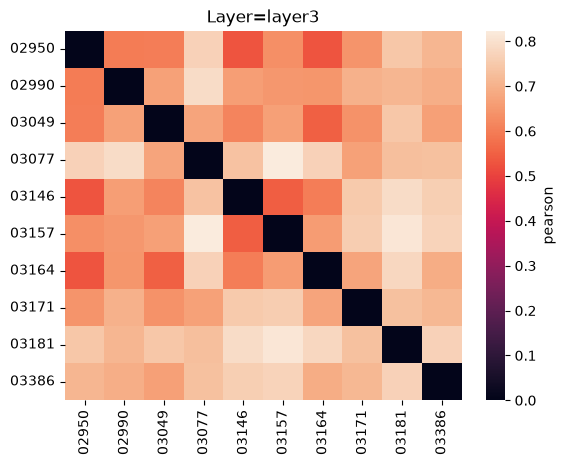

In [40]:
# visualising RDM 

from pathlib import Path

rdm_files = list(Path("RoomLayout_RDMs_NSD_last2").rglob("RDM_layer*.npz"))

print("Found:", len(rdm_files), "RDM files")

for f in rdm_files[:20]:
    print(f)

from net2brain.rdm_creation import LayerRDM

rdm = LayerRDM.from_file("RoomLayout_RDMs_NSD_last2/RDM_layer3.npz")
print("Class:", rdm)
rdm.plot(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### RSA

In [41]:
from net2brain.evaluations.rsa import RSA

# Get path to RDMs
model_rdms = "./RoomLayout_RDMs_NSD_last2"

# Start RSA
roomLayout_visual_evaluation = RSA(model_rdms, 
                  "./NSD_visual_RDMs", 
                 model_name="Taskonomy Room Layout")

df_roomLayout_visual = roomLayout_visual_evaluation.evaluate() # Evaluation - Returns a pandas dataframe

display(df_roomLayout_visual)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) hV4_lh,(0) RDM_layer3.npz,Taskonomy Room Layout,0.000673,0.677267,"[0.0009517587075209778, 0.0009415748163528842,...",0.000173,0.000093,0.099376,0.262878
1,(0) hV4_lh,(1) RDM_layer4.npz,Taskonomy Room Layout,0.001164,1.170980,"[0.0013537074568657221, 0.001299898507863618, ...",0.000180,0.000162,0.099376,0.262878
2,(1) hV4_rh,(0) RDM_layer3.npz,Taskonomy Room Layout,0.000879,0.885163,"[0.0012259819492591115, 0.0010990553137506173,...",0.000312,0.000134,0.099353,0.262107
3,(1) hV4_rh,(1) RDM_layer4.npz,Taskonomy Room Layout,0.001434,1.443142,"[0.002487412447730845, 0.0017906233173689819, ...",0.000612,0.000244,0.099353,0.262107
4,(2) V1d_lh,(0) RDM_layer3.npz,Taskonomy Room Layout,0.001580,0.897124,"[0.0021195762364880177, 0.0020493962527601472,...",0.000097,0.000199,0.176120,0.335863
5,(2) V1d_lh,(1) RDM_layer4.npz,Taskonomy Room Layout,0.002089,1.185844,"[0.002410524829830582, 0.002725830425877636, 0...",0.000048,0.000237,0.176120,0.335863
6,(3) V1d_rh,(0) RDM_layer3.npz,Taskonomy Room Layout,0.001684,0.985914,"[0.0018738944588879126, 0.002500867127609166, ...",0.000069,0.000201,0.170802,0.331561
7,(3) V1d_rh,(1) RDM_layer4.npz,Taskonomy Room Layout,0.002088,1.222195,"[0.002405479412511962, 0.003039514396477545, 0...",0.000052,0.000239,0.170802,0.331561
8,(4) V1v_lh,(0) RDM_layer3.npz,Taskonomy Room Layout,0.002025,1.097049,"[0.0026177646063015093, 0.0019208113132306174,...",0.000056,0.000235,0.184608,0.344487
9,(4) V1v_lh,(1) RDM_layer4.npz,Taskonomy Room Layout,0.003917,2.121699,"[0.004582447297365788, 0.003111601052388647, 0...",0.000062,0.000461,0.184608,0.344487


In [42]:
# against PPa

roomLayout_ppa_evaluation = RSA(
    "./RoomLayout_RDMs_NSD_last2",
    "./NSD_PPA_RDMs",
    model_name="Taskonomy Room Layout"
)

df_roomLayout_ppa = roomLayout_ppa_evaluation.evaluate()

display(df_roomLayout_ppa)

,ROI,Layer,Model,R2,%R2,R2_array,Significance,SEM,LNC,UNC
0,(0) PPA_lh,(0) RDM_layer3.npz,Taskonomy Room Layout,0.000956,0.563073,"[0.0006793744430188894, 0.0014618233254731195,...",0.000256,0.000141,0.169846,0.329043
1,(0) PPA_lh,(1) RDM_layer4.npz,Taskonomy Room Layout,0.003884,2.286878,"[0.0022539825472139355, 0.006103176283423156, ...",0.000156,0.000529,0.169846,0.329043
2,(1) PPA_rh,(0) RDM_layer3.npz,Taskonomy Room Layout,0.001127,0.588621,"[0.0004234997705011811, 0.0016879261405715878,...",0.000850,0.000203,0.191527,0.349057
3,(1) PPA_rh,(1) RDM_layer4.npz,Taskonomy Room Layout,0.004533,2.366730,"[0.0020765177239063562, 0.007107855354596152, ...",0.000358,0.000705,0.191527,0.349057


## verify Features

In [43]:
## verify all feature exists
import os

feature_folders = [
    "Depth_feats_NSD_last2",
    "Euclidean_feats_NSD_last2",
    "Keypoints3D_feats_NSD_last2",
    "Normal_feats_NSD_last2",
    "Curvature_feats_NSD_last2",
    "RoomLayout_feats_NSD_last2"
]

for folder in feature_folders:
    exists = os.path.exists(folder)
    
    if exists:
        files = os.listdir(folder)
        print(f"✓ {folder}")
        print(f"  Number of items: {len(files)}")
    else:
        print(f"✗ {folder} NOT FOUND")



✓ Depth_feats_NSD_last2
  Number of items: 2
✓ Euclidean_feats_NSD_last2
  Number of items: 2
✓ Keypoints3D_feats_NSD_last2
  Number of items: 2
✓ Normal_feats_NSD_last2
  Number of items: 2
✓ Curvature_feats_NSD_last2
  Number of items: 2
✓ RoomLayout_feats_NSD_last2
  Number of items: 2


## Evaluation

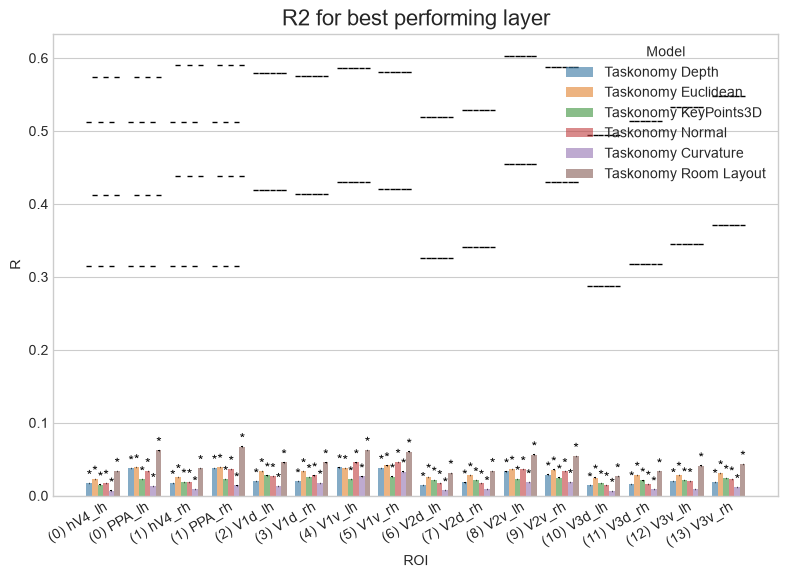

In [44]:
from net2brain.evaluations.plotting import Plotting

plotter = Plotting([
    df_depth_visual,
    df_depth_ppa,
    df_euc_visual,
    df_euc_ppa,
    df_kp3d_visual,
    df_kp3d_ppa,
    df_normal_visual,
    df_normal_ppa,
    df_curvature_visual,
    df_curvature_ppa,
    df_roomLayout_visual,
    df_roomLayout_ppa
])

results_dataframe = plotter.plot(metric="R")

In [45]:
#dataframe containing all layers

import pandas as pd
import re

all_layers_data = []

ppa_results = {
    "Depth": df_depth_ppa,
    "Euclidean": df_euc_ppa,
    "Keypoints3D": df_kp3d_ppa,
    "Normal": df_normal_ppa,
    "Curvature": df_curvature_ppa,
    "Room Layout": df_roomLayout_ppa
}

visual_results = {
    "Depth": df_depth_visual,
    "Euclidean": df_euc_visual,
    "Keypoints3D": df_kp3d_visual,
    "Normal": df_normal_visual,
    "Curvature": df_curvature_visual,
    "Room Layout": df_roomLayout_visual  # no R data for Room Layout 
}

all_results = ppa_results.copy()  # visual_results.copy()

for model_name, df in all_results.items():
    for _, row in df.iterrows():
        layer_match = re.search(r'layer(\d+)', row["Layer"])
        
        if layer_match:
            layer_number = int(layer_match.group(1))
        else:
            layer_number = None
        
        all_layers_data.append({
            "Model": model_name,
            "Layer_Number": layer_number,
            "R": row.get("R", None),
            "R2": row["R2"],
            "SEM": row["SEM"],
            "Significance": row["Significance"],
            "ROI": row["ROI"]
        })


df_all_layers = pd.DataFrame(all_layers_data)

df_all_layers = df_all_layers.sort_values(
    ["Layer_Number", "Model"]
).reset_index(drop=True)

display(df_all_layers)

,Model,Layer_Number,R,R2,SEM,Significance,ROI
0,Curvature,3,0.013276,0.000176,0.000029,0.000487,(0) PPA_lh
1,Curvature,3,0.014102,0.000199,0.000030,0.000315,(1) PPA_rh
2,Depth,3,0.037559,0.001411,0.000309,0.002594,(0) PPA_lh
3,Depth,3,0.038340,0.001470,0.000248,0.000578,(1) PPA_rh
4,Euclidean,3,0.033702,0.001136,0.000173,0.000312,(0) PPA_lh
5,Euclidean,3,0.033781,0.001141,0.000153,0.000140,(1) PPA_rh
6,Keypoints3D,3,0.018780,0.000353,0.000067,0.001208,(0) PPA_lh
7,Keypoints3D,3,0.019786,0.000391,0.000083,0.002218,(1) PPA_rh
8,Normal,3,0.033940,0.001152,0.000167,0.000232,(0) PPA_lh
9,Normal,3,0.036936,0.001364,0.000186,0.000158,(1) PPA_rh


In [46]:
# FUNCTION: convert RSA result dataframes into one dataframe

def prepare_layer_dataframe(results_dict, dataset_name):
    layers_data = []
    for model_name, df in results_dict.items():

        missing = [
            col for col in
            ["R", "R2", "SEM", "Significance", "ROI", "Layer"]
            if col not in df.columns
        ]
        if missing:
            print(f"{model_name} missing: {missing}")


        for _, row in df.iterrows():
            # Extract numerical layer number
            layer_match = re.search(
                r'layer(\d+)',
                str(row["Layer"]),
                re.IGNORECASE
            )

            if layer_match:
                layer_number = int(layer_match.group(1))
            else:
                layer_number = None

            layers_data.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Layer_Number": layer_number,
                "R": row.get("R"),
                "R2": row["R2"],
                "SEM": row["SEM"],
                "Significance": row["Significance"],
                "ROI": row["ROI"]
            })

    return pd.DataFrame(layers_data)

df_visual_layers = prepare_layer_dataframe(
    visual_results,
    "Visual"
)


df_ppa_layers = prepare_layer_dataframe(
    ppa_results,
    "PPA"
)

print("VISUAL:")
print(df_visual_layers.shape)
display(df_visual_layers.head())


print("\nPPA:")
print(df_ppa_layers.shape)
display(df_ppa_layers.head())

VISUAL:
(168, 8)


,Dataset,Model,Layer_Number,R,R2,SEM,Significance,ROI
0,Visual,Depth,3,0.017582,0.000309,0.000038,0.000087,(0) hV4_lh
1,Visual,Depth,4,0.010707,0.000115,0.000024,0.001880,(0) hV4_lh
2,Visual,Depth,3,0.017605,0.000310,0.000051,0.000526,(1) hV4_rh
3,Visual,Depth,4,0.009019,0.000081,0.000018,0.002400,(1) hV4_rh
4,Visual,Depth,3,0.019798,0.000392,0.000079,0.001598,(2) V1d_lh



PPA:
(24, 8)


,Dataset,Model,Layer_Number,R,R2,SEM,Significance,ROI
0,PPA,Depth,3,0.037559,0.001411,0.000309,0.002594,(0) PPA_lh
1,PPA,Depth,4,0.026605,0.000708,0.000185,0.006444,(0) PPA_lh
2,PPA,Depth,3,0.038340,0.001470,0.000248,0.000578,(1) PPA_rh
3,PPA,Depth,4,0.027975,0.000783,0.000160,0.001764,(1) PPA_rh
4,PPA,Euclidean,3,0.033702,0.001136,0.000173,0.000312,(0) PPA_lh


In [47]:
# combine visual and PPA dataframes into one dataframe

df_roi_layers = pd.concat(
    [
        df_visual_layers,
        df_ppa_layers
    ],
    ignore_index=True
)

df_roi_layers = df_roi_layers.sort_values(
    [
        "Dataset",
        "ROI",
        "Model",
        "Layer_Number"
    ]
).reset_index(drop=True)

In [48]:
def assign_roi_group(roi):
    roi = str(roi).lower()

    if "v1d" in roi or "v1v" in roi:
        return "V1"

    elif "v2d" in roi or "v2v" in roi:
        return "V2"

    elif "hv4" in roi:
        return "V4"

    elif "ppa" in roi:
        return "PPA"

    else:
        return None


df_roi_layers["ROI_Group"] = (
    df_roi_layers["ROI"]
    .apply(assign_roi_group)
)

df_v1_v2_v4_ppa = df_roi_layers[
    df_roi_layers["ROI_Group"].isin(
        ["V1", "V2", "V4", "PPA"]
    )
].copy()

print(
    df_v1_v2_v4_ppa[
        ["ROI", "ROI_Group"]
    ]
    .drop_duplicates()
    .sort_values("ROI_Group")
)


            ROI ROI_Group
0    (0) PPA_lh       PPA
12   (1) PPA_rh       PPA
96   (2) V1d_lh        V1
108  (3) V1d_rh        V1
120  (4) V1v_lh        V1
132  (5) V1v_rh        V1
144  (6) V2d_lh        V2
156  (7) V2d_rh        V2
168  (8) V2v_lh        V2
180  (9) V2v_rh        V2
24   (0) hV4_lh        V4
36   (1) hV4_rh        V4


In [49]:
def assign_roi_group(roi):
    roi = str(roi).lower()

    # V1
    if "v1d" in roi or "v1v" in roi:
        return "V1"

    # V2
    elif "v2d" in roi or "v2v" in roi:
        return "V2"

    # V4
    elif "hv4" in roi:
        return "V4"

    # PPA
    elif "ppa" in roi:
        return "PPA"

    else:
        return None

df_roi_layers["ROI_Group"] = (
    df_roi_layers["ROI"]
    .apply(assign_roi_group)
)

df_plot = df_roi_layers[
    df_roi_layers["ROI_Group"].isin(
        ["V1", "V2", "V4", "PPA"]
    )
].copy()

print(
    df_v1_v2_v4_ppa[
        ["ROI", "ROI_Group"]
    ]
    .drop_duplicates()
    .sort_values("ROI_Group")
)


            ROI ROI_Group
0    (0) PPA_lh       PPA
12   (1) PPA_rh       PPA
96   (2) V1d_lh        V1
108  (3) V1d_rh        V1
120  (4) V1v_lh        V1
132  (5) V1v_rh        V1
144  (6) V2d_lh        V2
156  (7) V2d_rh        V2
168  (8) V2v_lh        V2
180  (9) V2v_rh        V2
24   (0) hV4_lh        V4
36   (1) hV4_rh        V4


In [50]:
df_plot_summary = (
    df_plot
    .groupby(
        [
            "Model",
            "ROI_Group",
            "Layer_Number"
        ]
    )["R"]
    .mean()
    .reset_index()
)

display(df_plot_summary)

,Model,ROI_Group,Layer_Number,R
0,Curvature,PPA,3,0.013689
1,Curvature,PPA,4,0.010616
2,Curvature,V1,3,0.019756
3,Curvature,V1,4,0.022289
4,Curvature,V2,3,0.010792
5,Curvature,V2,4,0.013085
6,Curvature,V4,3,0.006931
7,Curvature,V4,4,0.008028
8,Depth,PPA,3,0.037949
9,Depth,PPA,4,0.027290


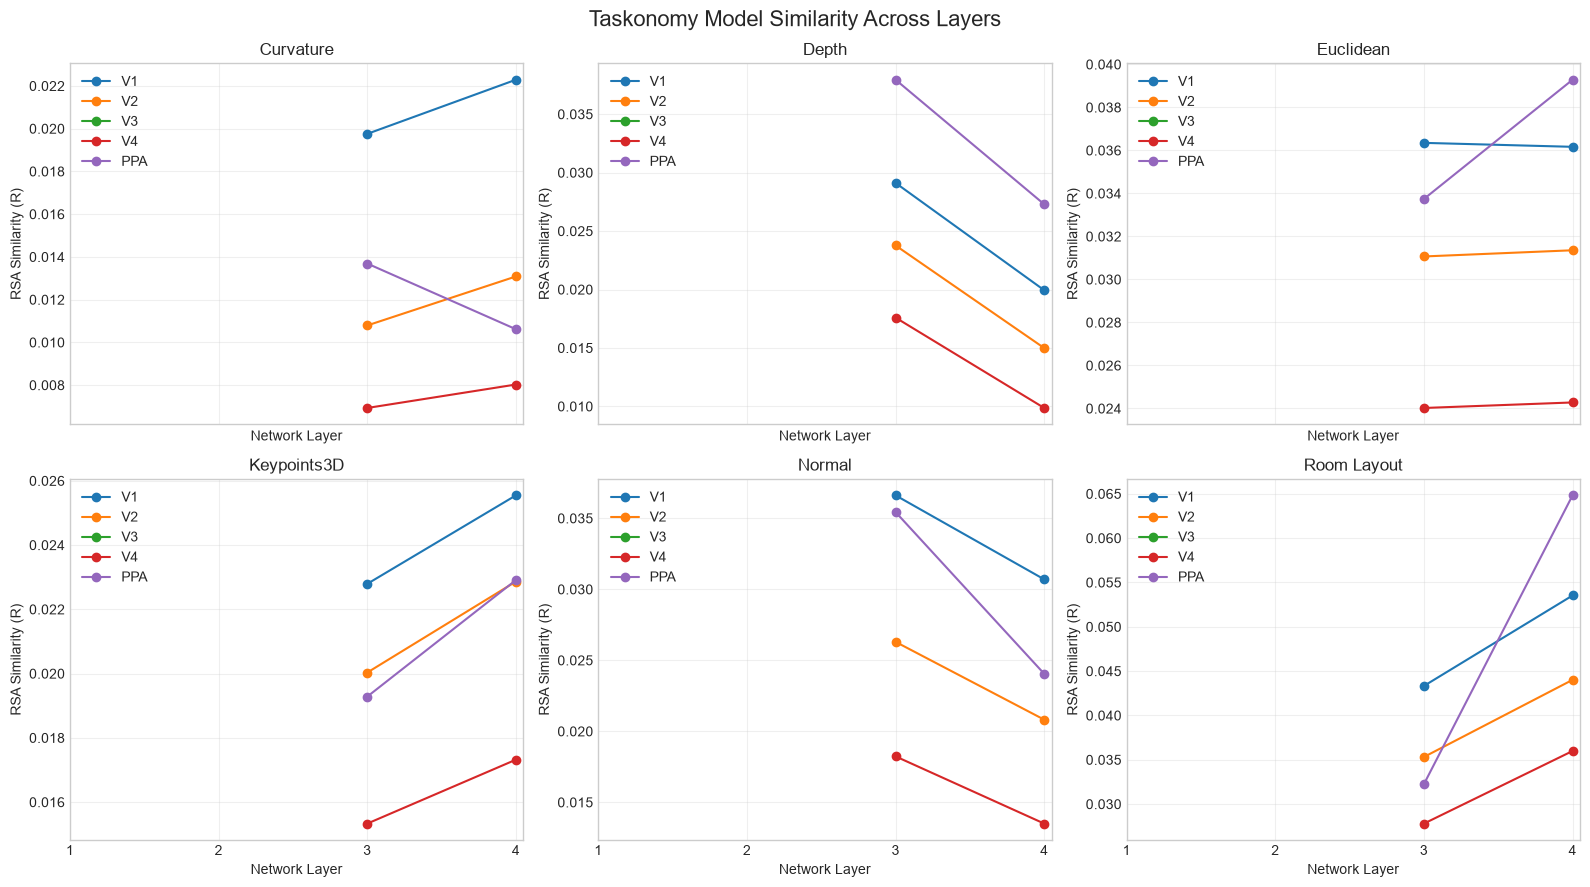

In [51]:
# brain-model similarity change as we move from Layer 1 → Layer 4
import matplotlib.pyplot as plt

models = df_plot_summary["Model"].unique()

roi_order = ["V1", "V2","V3", "V4", "PPA"]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
    sharex=True
)

axes = axes.flatten()


for ax, model_name in zip(axes, models):

    model_data = df_plot_summary[
        df_plot_summary["Model"] == model_name
    ]


    for roi_name in roi_order:

        roi_data = model_data[
            model_data["ROI_Group"] == roi_name
        ].sort_values("Layer_Number")


        ax.plot(
            roi_data["Layer_Number"],
            roi_data["R"],
            marker="o",
            label=roi_name
        )


    ax.set_title(model_name)

    ax.set_xlabel("Network Layer")

    ax.set_ylabel("RSA Similarity (R)")

    ax.set_xticks([1, 2, 3, 4])

    ax.grid(True, alpha=0.3)

    ax.legend()


plt.suptitle(
    "Taskonomy Model Similarity Across Layers",
    fontsize=16
)

plt.tight_layout()

plt.show()

## VPA


### VPA for 4 RDM (4 layers)

In [55]:
import os

print("Depth:")
print(os.listdir("Depth_RDMs_NSD_last2"))

print("\nEuclidean:")
print(os.listdir("Euclidean_RDMs_NSD_last2"))

print("\nKeypoints3D:")
print(os.listdir("Keypoints3D_RDMs_NSD_last2"))

print("\nNormal:")
print(os.listdir("Normal_RDMs_NSD_last2"))

Depth:
['RDM_layer3.npz', 'RDM_layer4.npz']

Euclidean:
['RDM_layer3.npz', 'RDM_layer4.npz']

Keypoints3D:
['RDM_layer3.npz', 'RDM_layer4.npz']

Normal:
['RDM_layer3.npz', 'RDM_layer4.npz']


In [56]:
from net2brain.evaluations.variance_partitioning_analysis import VPA
import os

depth_rdms = [os.path.join("Depth_RDMs_NSD_last2", "RDM_layer3.npz"),
            os.path.join("Depth_RDMs_NSD_last2", "RDM_layer4.npz")
]

euclidean_rdms = [
    os.path.join("Euclidean_RDMs_NSD_last2", "RDM_layer3.npz"),
    os.path.join("Euclidean_RDMs_NSD_last2", "RDM_layer4.npz")
]

keypoints3d_rdms = [
    os.path.join("Keypoints3D_RDMs_NSD_last2", "RDM_layer3.npz"),
    os.path.join("Keypoints3D_RDMs_NSD_last2", "RDM_layer4.npz")
]

normal_rdms = [
    os.path.join("Normal_RDMs_NSD_last2", "RDM_layer3.npz"),
    os.path.join("Normal_RDMs_NSD_last2", "RDM_layer4.npz")
]

for name, paths in {
    "Depth": depth_rdms,
    "Euclidean": euclidean_rdms,
    "Keypoints3D": keypoints3d_rdms,
    "Normal": normal_rdms
}.items():
    
    print(name)
    
    for path in paths:
        print(path, "→", os.path.exists(path))
    
    print()

Depth
Depth_RDMs_NSD_last2\RDM_layer3.npz → True
Depth_RDMs_NSD_last2\RDM_layer4.npz → True

Euclidean
Euclidean_RDMs_NSD_last2\RDM_layer3.npz → True
Euclidean_RDMs_NSD_last2\RDM_layer4.npz → True

Keypoints3D
Keypoints3D_RDMs_NSD_last2\RDM_layer3.npz → True
Keypoints3D_RDMs_NSD_last2\RDM_layer4.npz → True

Normal
Normal_RDMs_NSD_last2\RDM_layer3.npz → True
Normal_RDMs_NSD_last2\RDM_layer4.npz → True



In [57]:
independent_variables = [
    depth_rdms,
    euclidean_rdms,
    keypoints3d_rdms,
    normal_rdms
]

variable_names = [
    "Depth",
    "Euclidean",
    "Keypoints3D",
    "Normal"
]

In [58]:
from pathlib import Path

nsd_path = Path("../Algonauts23_shared_Net2Brain")

brain_rois = {}

visual_rois = [
    "V1d",
    "V1v",
    "V2d",
    "V2v",
    "V3d",
    "V3v",
    "hV4"
]

for roi in visual_rois:
    for hemisphere in ["lh", "rh"]:

        roi_name = f"{roi}_{hemisphere}"

        brain_rois[roi_name] = [
            nsd_path
            / f"subj{subject_num:02d}"
            / "rdms"
            / f"{roi}_{hemisphere}_subj{subject_num:02d}.npy"
            for subject_num in range(1, 9)
        ]


# PPA
for hemisphere in ["lh", "rh"]:

    roi_name = f"PPA_{hemisphere}"

    brain_rois[roi_name] = [
        nsd_path
        / f"subj{subject_num:02d}"
        / "rdms"
        / f"PPA_{hemisphere}_subj{subject_num:02d}.npy"
        for subject_num in range(1, 9)
    ]


print("Number of ROIs:", len(brain_rois))

for roi_name, paths in brain_rois.items():

    print(
        roi_name,
        "→",
        len(paths),
        "subject files"
    )

    print(
        "   All exist:",
        all(path.exists() for path in paths)
    )

Number of ROIs: 16
V1d_lh → 8 subject files
   All exist: True
V1d_rh → 8 subject files
   All exist: True
V1v_lh → 8 subject files
   All exist: True
V1v_rh → 8 subject files
   All exist: True
V2d_lh → 8 subject files
   All exist: True
V2d_rh → 8 subject files
   All exist: True
V2v_lh → 8 subject files
   All exist: True
V2v_rh → 8 subject files
   All exist: True
V3d_lh → 8 subject files
   All exist: True
V3d_rh → 8 subject files
   All exist: True
V3v_lh → 8 subject files
   All exist: True
V3v_rh → 8 subject files
   All exist: True
hV4_lh → 8 subject files
   All exist: True
hV4_rh → 8 subject files
   All exist: True
PPA_lh → 8 subject files
   All exist: True
PPA_rh → 8 subject files
   All exist: True


In [59]:
import numpy as np
import os

vpa_brain_folder = "VPA_brain_data_NSD"

os.makedirs(
    vpa_brain_folder,
    exist_ok=True
)

brain_vpa_paths = {}

for roi_name, subject_paths in brain_rois.items():

    print(
        "\nProcessing:",
        roi_name
    )

    subject_rdms = []

    for path in subject_paths:

        # Load condensed NSD RDM
        rdm = np.load(path)

        print(
            " ",
            path.name,
            "→",
            rdm.shape
        )

        subject_rdms.append(rdm)

    # Stack 8 subjects
    brain_data = np.stack(subject_rdms)

    print(
        " ",
        roi_name,
        "combined shape:",
        brain_data.shape
    )

    # Add singleton time dimension
    # (subjects, pairs)
    # →
    # (subjects, 1, pairs)

    brain_vpa = brain_data[
        :,
        np.newaxis,
        :
    ]

    print(
        " ",
        roi_name,
        "VPA shape:",
        brain_vpa.shape
    )

    save_path = os.path.join(
        vpa_brain_folder,
        f"{roi_name}_vpa.npy"
    )

    np.save(
        save_path,
        brain_vpa
    )

    brain_vpa_paths[roi_name] = save_path


print("\nSaved brain VPA files:")

for roi_name, path in brain_vpa_paths.items():

    print(
        roi_name,
        "→",
        path,
        "→",
        os.path.exists(path)
    )


Processing: V1d_lh
  V1d_lh_subj01.npy → (379756,)
  V1d_lh_subj02.npy → (379756,)
  V1d_lh_subj03.npy → (379756,)
  V1d_lh_subj04.npy → (379756,)
  V1d_lh_subj05.npy → (379756,)
  V1d_lh_subj06.npy → (379756,)
  V1d_lh_subj07.npy → (379756,)
  V1d_lh_subj08.npy → (379756,)
  V1d_lh combined shape: (8, 379756)
  V1d_lh VPA shape: (8, 1, 379756)

Processing: V1d_rh
  V1d_rh_subj01.npy → (379756,)
  V1d_rh_subj02.npy → (379756,)
  V1d_rh_subj03.npy → (379756,)
  V1d_rh_subj04.npy → (379756,)
  V1d_rh_subj05.npy → (379756,)
  V1d_rh_subj06.npy → (379756,)
  V1d_rh_subj07.npy → (379756,)
  V1d_rh_subj08.npy → (379756,)
  V1d_rh combined shape: (8, 379756)
  V1d_rh VPA shape: (8, 1, 379756)

Processing: V1v_lh
  V1v_lh_subj01.npy → (379756,)
  V1v_lh_subj02.npy → (379756,)
  V1v_lh_subj03.npy → (379756,)
  V1v_lh_subj04.npy → (379756,)
  V1v_lh_subj05.npy → (379756,)
  V1v_lh_subj06.npy → (379756,)
  V1v_lh_subj07.npy → (379756,)
  V1v_lh_subj08.npy → (379756,)
  V1v_lh combined shape: (8,

In [60]:
import pandas as pd

all_vpa_results = []

for roi_name, dependent_variable_vpa in brain_vpa_paths.items():

    print(
        "Running VPA for:",
        roi_name
    )

    VPA_eval = VPA(

        dependent_variable_vpa,

        independent_variables,

        variable_names

    )

    df_vpa = VPA_eval.evaluate(

        average_models=True

    )

    # Add ROI name to result

    df_vpa["ROI"] = roi_name


    all_vpa_results.append(
        df_vpa
    )


# Combine all ROIs

df_vpa_all = pd.concat(

    all_vpa_results,

    ignore_index=True

)

print(
    "Final shape:",
    df_vpa_all.shape
)

display(
    df_vpa_all.head()
)

Running VPA for: V1d_lh
Running VPA for: V1d_rh
Running VPA for: V1v_lh
Running VPA for: V1v_rh
Running VPA for: V2d_lh
Running VPA for: V2d_rh
Running VPA for: V2v_lh
Running VPA for: V2v_rh
Running VPA for: V3d_lh
Running VPA for: V3d_rh
Running VPA for: V3v_lh
Running VPA for: V3v_rh
Running VPA for: hV4_lh
Running VPA for: hV4_rh
Running VPA for: PPA_lh
Running VPA for: PPA_rh
Final shape: (448, 6)


,Variable,Description,Values,Significance,Color,ROI
0,R1,Depth Influence,"[[0.000361571710514097], [0.000415600326880039...",[0.0020060831946805647],None,V1d_lh
1,R2,Euclidean Influence,"[[0.0018545740945534739], [0.00151192048339066...",[1.7959218923425922e-05],None,V1d_lh
2,R3,Keypoints3D Influence,"[[0.001178258988576708], [0.000750338048460585...",[0.0003559812964558851],None,V1d_lh
3,R4,Normal Influence,"[[0.0014740173041566385], [0.00080388723366475...",[0.00037406191800384224],None,V1d_lh
4,R12,Combined Depth and Euclidean Influence,"[[0.001868691722586746], [0.001512053140357627...",[1.1134099175709991e-05],None,V1d_lh


In [61]:
df_vpa_filtered = df_vpa_all.query(
    "Variable in ['y1234', 'y1', 'y2', 'y3', 'y4']"
).reset_index(drop=True)

display(df_vpa_filtered)

,Variable,Description,Values,Significance,Color,ROI
0,y1,Unique Depth,"[[6.141099608636402e-05], [7.266646399384236e-...",[0.005247495114352356],None,V1d_lh
1,y2,Unique Euclidean,"[[0.0003817848092311227], [0.00049774168969618...",[7.50879034583057e-06],None,V1d_lh
2,y3,Unique Keypoints3D,"[[1.927755643671425e-06], [3.596033571739987e-...",[0.11933120749439391],None,V1d_lh
3,y4,Unique Normal,"[[0.00036989845979318314], [8.4211222260544e-0...",[0.008852570925755369],None,V1d_lh
4,y1234,Shared Variance Depth and Euclidean and Keypoi...,"[[0.0002715456019684037], [0.00021442216348621...",[0.0010480610736702878],None,V1d_lh
...,...,...,...,...,...,...
75,y1,Unique Depth,"[[0.0007393487903701867], [0.00023316457715905...",[0.07512745505570985],None,PPA_rh
76,y2,Unique Euclidean,"[[0.00017085404106431668], [0.0003679034729265...",[0.0010095741654078544],None,PPA_rh
77,y3,Unique Keypoints3D,"[[0.00018334525910201904], [0.0002140410507511...",[0.001773185380288919],None,PPA_rh
78,y4,Unique Normal,"[[0.0004239769355460776], [0.00069479961076435...",[0.0011621456807122481],None,PPA_rh


In [62]:
df_vpa_plot = df_vpa_filtered.copy()

df_vpa_plot["Significance"] = (
    df_vpa_plot["Significance"].apply(
        lambda x:
        float(np.asarray(x).squeeze())
    )
)

display(df_vpa_plot)

,Variable,Description,Values,Significance,Color,ROI
0,y1,Unique Depth,"[[6.141099608636402e-05], [7.266646399384236e-...",0.005247,None,V1d_lh
1,y2,Unique Euclidean,"[[0.0003817848092311227], [0.00049774168969618...",0.000008,None,V1d_lh
2,y3,Unique Keypoints3D,"[[1.927755643671425e-06], [3.596033571739987e-...",0.119331,None,V1d_lh
3,y4,Unique Normal,"[[0.00036989845979318314], [8.4211222260544e-0...",0.008853,None,V1d_lh
4,y1234,Shared Variance Depth and Euclidean and Keypoi...,"[[0.0002715456019684037], [0.00021442216348621...",0.001048,None,V1d_lh
...,...,...,...,...,...,...
75,y1,Unique Depth,"[[0.0007393487903701867], [0.00023316457715905...",0.075127,None,PPA_rh
76,y2,Unique Euclidean,"[[0.00017085404106431668], [0.0003679034729265...",0.001010,None,PPA_rh
77,y3,Unique Keypoints3D,"[[0.00018334525910201904], [0.0002140410507511...",0.001773,None,PPA_rh
78,y4,Unique Normal,"[[0.0004239769355460776], [0.00069479961076435...",0.001162,None,PPA_rh


In [63]:
print("ROIs:")
print(df_vpa_plot["ROI"].unique())
print("\nVariables:")
print(df_vpa_plot["Variable"].unique())
print("\nNumber of results per ROI:")
print(df_vpa_plot.groupby("ROI").size())

ROIs:
['V1d_lh' 'V1d_rh' 'V1v_lh' 'V1v_rh' 'V2d_lh' 'V2d_rh' 'V2v_lh' 'V2v_rh'
 'V3d_lh' 'V3d_rh' 'V3v_lh' 'V3v_rh' 'hV4_lh' 'hV4_rh' 'PPA_lh' 'PPA_rh']

Variables:
['y1' 'y2' 'y3' 'y4' 'y1234']

Number of results per ROI:
ROI
PPA_lh    5
PPA_rh    5
V1d_lh    5
V1d_rh    5
V1v_lh    5
V1v_rh    5
V2d_lh    5
V2d_rh    5
V2v_lh    5
V2v_rh    5
V3d_lh    5
V3d_rh    5
V3v_lh    5
V3v_rh    5
hV4_lh    5
hV4_rh    5
dtype: int64


V1d_lh


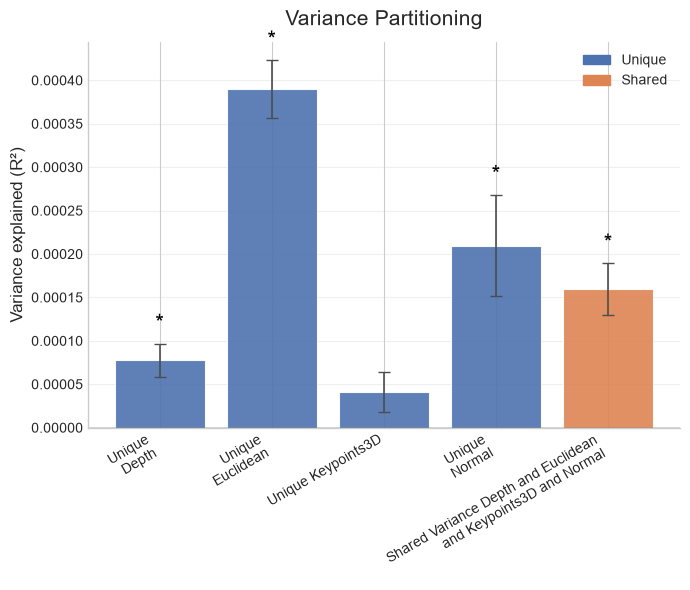

V2d_lh


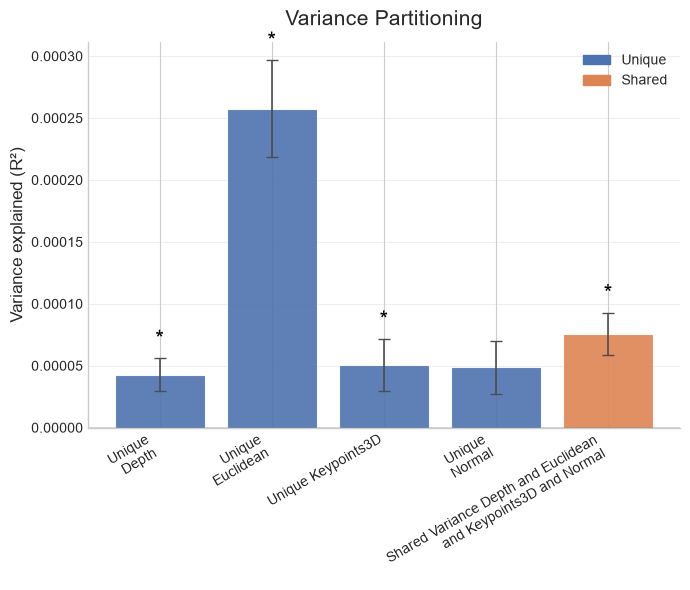

V3d_lh


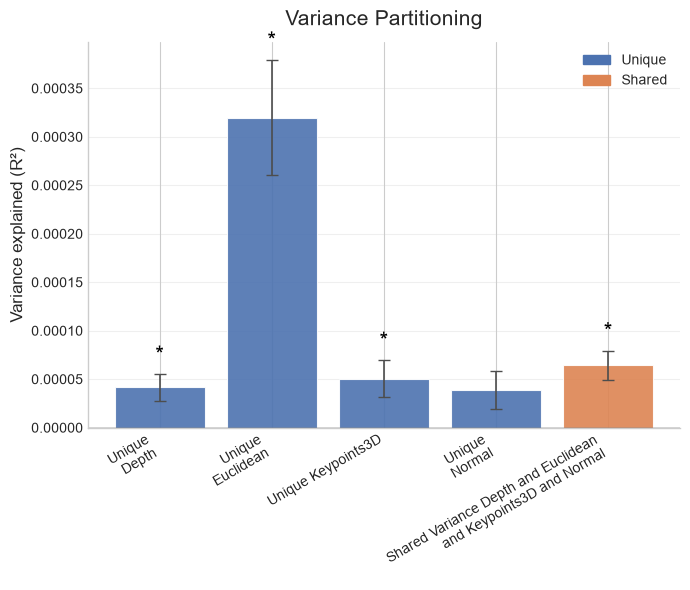

hV4_lh


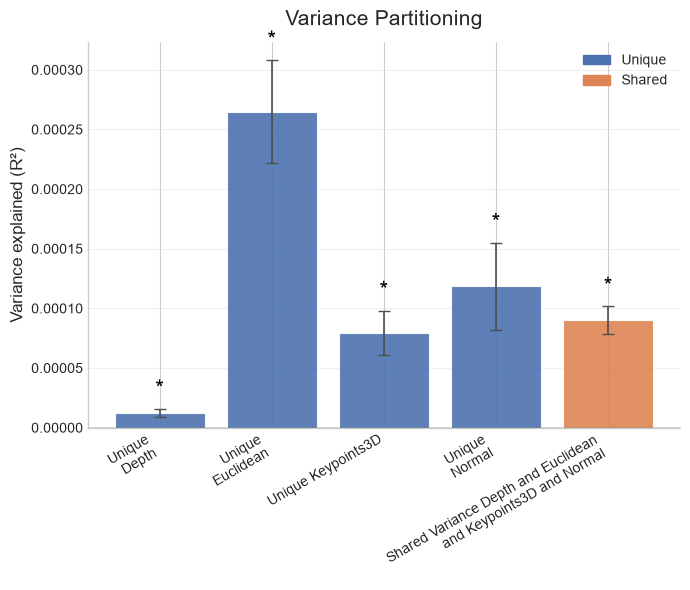

PPA_lh


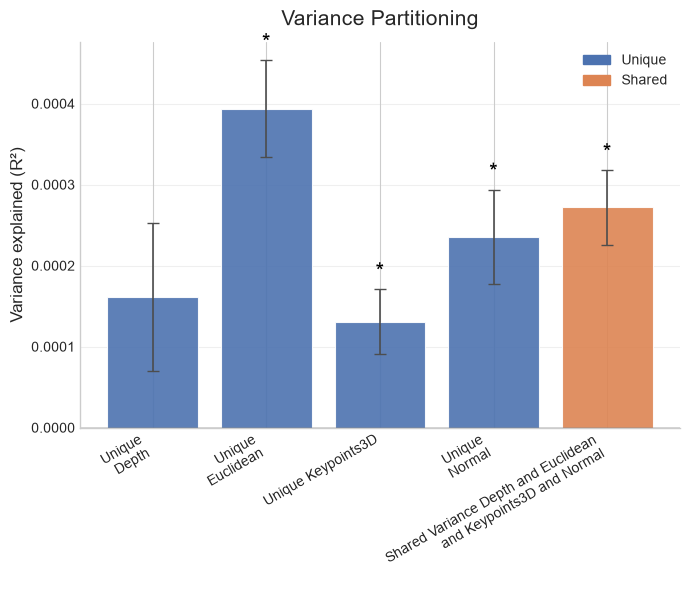

In [64]:
from net2brain.evaluations.plotting import Plotting

# df_ppa_vpa = df_vpa_plot[df_vpa_plot["ROI"] == "PPA"].copy()

for roi in [
    "V1d_lh",
    "V2d_lh",
    "V3d_lh",
    "hV4_lh",
    "PPA_lh"
]:

    print(roi)

    df_roi = df_vpa_plot[
        df_vpa_plot["ROI"] == roi
    ]

    plotter = Plotting(df_roi)
    plotter.plotting_components()

In [65]:
import numpy as np

df_plot = df_vpa_plot.copy()

df_plot["Mean"] = df_plot["Values"].apply(
    lambda x: np.mean(np.asarray(x))
)

#df_plot["Std"] = df_plot["Values"].apply(
#   lambda x: np.std(np.asarray(x), ddof=1))

df_plot["SEM"] = df_plot["Values"].apply(
    lambda x: np.std(np.asarray(x), ddof=1)
              / np.sqrt(len(np.asarray(x)))
)

In [67]:
import pandas as pd

pivot = df_plot.pivot(
    index="ROI",
    columns="Variable",
    values="Mean"
)

display(pivot.head())

Variable,y1,y1234,y2,y3,y4
ROI,,,,,
PPA_lh,0.000161,0.000272,0.000394,0.000131,0.000236
PPA_rh,0.000178,0.000316,0.000330,0.000110,0.000369
V1d_lh,0.000077,0.000160,0.000390,0.000041,0.000210
V1d_rh,0.000112,0.000152,0.000366,0.000041,0.000431
V1v_lh,0.000199,0.000426,0.000433,0.000375,0.001691


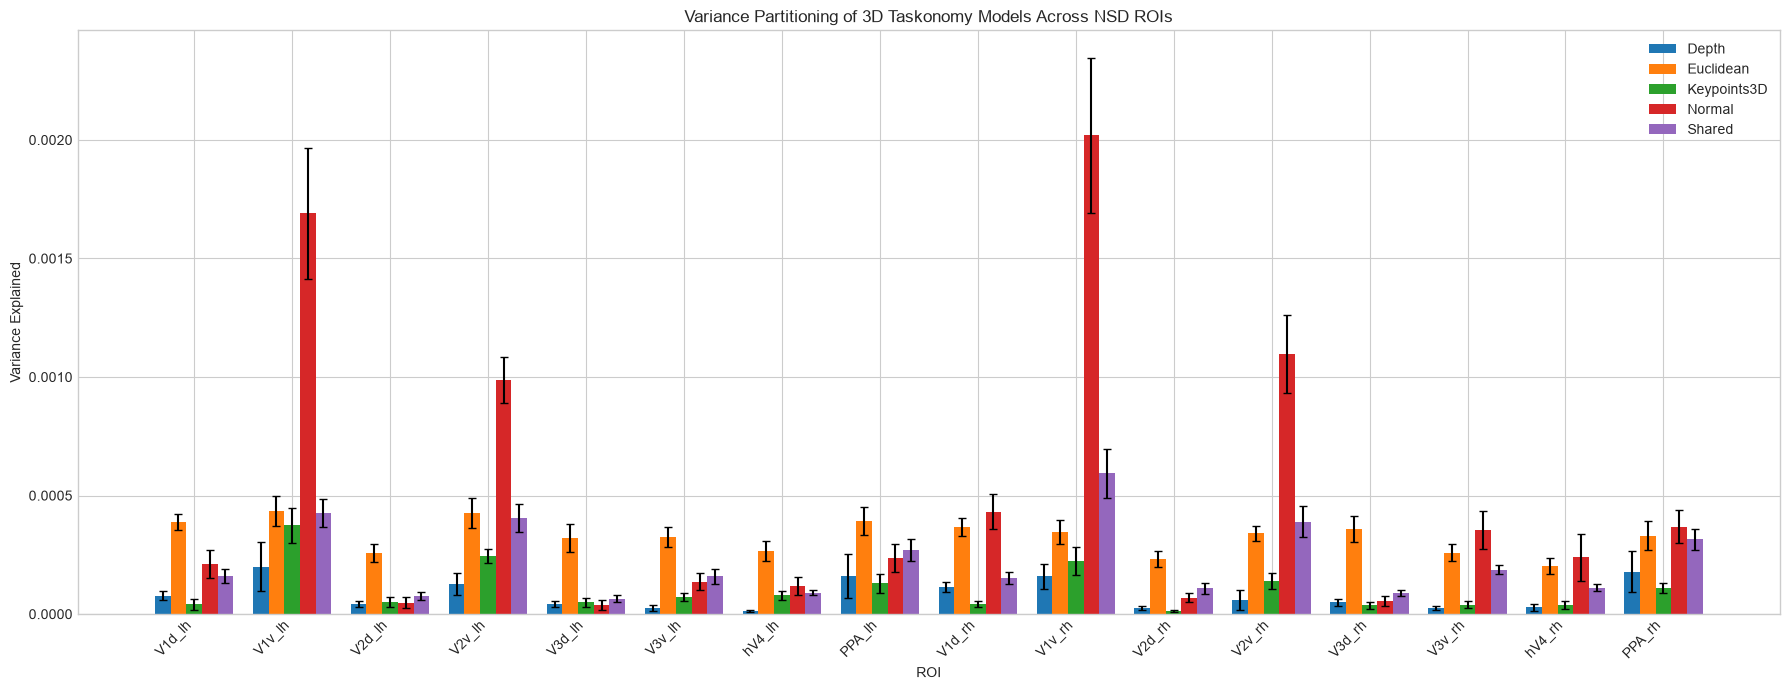

In [69]:
import matplotlib.pyplot as plt
import numpy as np

name_map = {
    "y1": "Depth",
    "y2": "Euclidean",
    "y3": "Keypoints3D",
    "y4": "Normal",
    "y1234": "Shared"
}

df_plot["Component"] = df_plot["Variable"].map(name_map)

# Fixed ROI order for NSD
roi_order = [
    "V1d_lh",
    "V1v_lh",
    "V2d_lh",
    "V2v_lh",
    "V3d_lh",
    "V3v_lh",
    "hV4_lh",
    "PPA_lh",
    "V1d_rh",
    "V1v_rh",
    "V2d_rh",
    "V2v_rh",
    "V3d_rh",
    "V3v_rh",
    "hV4_rh",
    "PPA_rh"
]

# Keep only ROIs that actually exist
rois = [
    roi for roi in roi_order
    if roi in df_plot["ROI"].unique()
]

components = [
    "Depth",
    "Euclidean",
    "Keypoints3D",
    "Normal",
    "Shared"
]

x = np.arange(len(rois))
width = 0.16

fig, ax = plt.subplots(figsize=(18, 7))

for i, comp in enumerate(components):

    subset = df_plot[
        df_plot["Component"] == comp
    ]

    means = []
    sems = []

    for roi in rois:

        row = subset[
            subset["ROI"] == roi
        ]

        if not row.empty:
            means.append(row.iloc[0]["Mean"])
            sems.append(row.iloc[0]["SEM"])
        else:
            means.append(np.nan)
            sems.append(0)

    ax.bar(
        x + (i - 2) * width,
        means,
        width,
        label=comp,
        yerr=sems,
        capsize=3
    )

ax.set_xticks(x)
ax.set_xticklabels(
    rois,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Variance Explained")
ax.set_xlabel("ROI")
ax.set_title(
    "Variance Partitioning of 3D Taskonomy Models Across NSD ROIs"
)

ax.legend()

plt.tight_layout()
plt.show()

## Combine Average 3D

In [72]:
import numpy as np
from pathlib import Path

# 3D TASKONOMY RDM COMBINATION

models_3d = {
    "Depth": Path("Depth_RDMs_NSD_last2"),
    "Euclidean": Path("Euclidean_RDMs_NSD_last2"),
    "KeyPoints3D": Path("KeyPoints3D_RDMs_NSD_last2"),
    "Normal": Path("Normal_RDMs_NSD_last2"),
}

# Output file
output_file = Path("3D_RDM_NSD.npz")

# Last two ResNet-50 encoder layers
layers = ["RDM_layer3.npz", "RDM_layer4.npz"]

def load_rdm(path):
    """Load the RDM array from a Net2Brain .npz file."""
    
    data = np.load(path, allow_pickle=True)
    
    print(f"\nLoading: {path}")
    print("Keys:", data.files)
    
    if "rdm" not in data.files:
        raise KeyError(f"'rdm' not found in {path}. Available keys: {data.files}")
    
    rdm = data["rdm"]
    
    # Handle object arrays if necessary
    if rdm.dtype == object and rdm.ndim == 0:
        rdm = rdm.item()
    
    rdm = np.asarray(rdm, dtype=float)
    
    print("Shape:", rdm.shape)
    
    return rdm

# Load all selected model/layer RDMs
rdms = []

for model_name, model_path in models_3d.items():
    
    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)
    
    if not model_path.exists():
        raise FileNotFoundError(
            f"Folder not found: {model_path.resolve()}"
        )
    
    for layer_file in layers:
        
        rdm_path = model_path / layer_file
        
        if not rdm_path.exists():
            raise FileNotFoundError(
                f"RDM file not found: {rdm_path.resolve()}"
            )
        
        rdm = load_rdm(rdm_path)
        
        rdms.append(rdm)

# Check that all RDMs have the same shape
print("\n" + "=" * 60)
print("CHECKING RDM SHAPES")
print("=" * 60)

for i, rdm in enumerate(rdms):
    print(f"RDM {i+1}: {rdm.shape}")

shapes = [rdm.shape for rdm in rdms]

if len(set(shapes)) != 1:
    raise ValueError(
        f"RDM shapes are not identical: {shapes}"
    )

print("\nAll RDMs have the same shape:", shapes[0])

# Average all selected model/layer RDMs
rdms_stack = np.stack(rdms, axis=0)

print("\nStacked RDM shape:", rdms_stack.shape)

rdm_3d = np.mean(rdms_stack, axis=0)

print("Combined 3D RDM shape:", rdm_3d.shape)

# Save
np.savez(
    output_file,
    rdm=rdm_3d
)

print("\nSaved combined 3D RDM to:")
print(output_file.resolve())

# Basic verification

print("\n" + "=" * 60)
print("VERIFICATION")
print("=" * 60)

print("Minimum:", np.min(rdm_3d))
print("Maximum:", np.max(rdm_3d))
print("Mean:", np.mean(rdm_3d))
print("NaN:", np.isnan(rdm_3d).any())
print("Inf:", np.isinf(rdm_3d).any())


Depth

Loading: Depth_RDMs_NSD_last2\RDM_layer3.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (379756,)

Loading: Depth_RDMs_NSD_last2\RDM_layer4.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (379756,)

Euclidean

Loading: Euclidean_RDMs_NSD_last2\RDM_layer3.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (379756,)

Loading: Euclidean_RDMs_NSD_last2\RDM_layer4.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (379756,)

KeyPoints3D

Loading: KeyPoints3D_RDMs_NSD_last2\RDM_layer3.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (379756,)

Loading: KeyPoints3D_RDMs_NSD_last2\RDM_layer4.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (379756,)

Normal

Loading: Normal_RDMs_NSD_last2\RDM_layer3.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (379756,)

Loading: Normal_RDMs_NSD_last2\RDM_layer4.npz
Keys: ['rdm', 'stimuli_name', 'layer_name', 'meta']
Shape: (379756,)

CHECKING RDM SHAPE

In [73]:
import numpy as np
from pathlib import Path

models_3d = {
    "Depth": Path("Depth_RDMs_NSD_last2"),
    "Euclidean": Path("Euclidean_RDMs_NSD_last2"),
    "KeyPoints3D": Path("KeyPoints3D_RDMs_NSD_last2"),
    "Normal": Path("Normal_RDMs_NSD_last2"),
}

reference = None

for model_name, folder in models_3d.items():
    for layer in ["RDM_layer3.npz", "RDM_layer4.npz"]:
        path = folder / layer
        data = np.load(path, allow_pickle=True)

        stimuli = data["stimuli_name"]

        if reference is None:
            reference = stimuli
            print(f"Reference: {model_name} {layer}")
        else:
            same = np.array_equal(reference, stimuli)
            print(f"{model_name} {layer}: same stimulus order = {same}")

            if not same:
                print("WARNING: stimulus order differs!")

Reference: Depth RDM_layer3.npz
Depth RDM_layer4.npz: same stimulus order = True
Euclidean RDM_layer3.npz: same stimulus order = True
Euclidean RDM_layer4.npz: same stimulus order = True
KeyPoints3D RDM_layer3.npz: same stimulus order = True
KeyPoints3D RDM_layer4.npz: same stimulus order = True
Normal RDM_layer3.npz: same stimulus order = True
Normal RDM_layer4.npz: same stimulus order = True


## VPA (2D,3D, Sem) -- unfinish

In [ ]:
import numpy as np

for path in [
    "2D_RDM_NSD.npz",
    "3D_RDM_NSD.npz",
    "Semantic_RDM_NSD.npz"
]:
    d = np.load(path, allow_pickle=True)

    print("\n", path)
    print("keys:", d.files)
    print("shape:", d["rdm"].shape)

    if "stimuli_name" in d.files:
        print("stimuli:", len(d["stimuli_name"]))


 2D_RDM.npz
keys: ['rdm']
shape: (1225,)

 3D_RDM.npz
keys: ['rdm']
shape: (1225,)

 Semantic_RDM_Bonner.npz
keys: ['rdm', 'stimuli_name', 'model_names', 'layers']
shape: (1225,)
stimuli: 50


In [68]:
import numpy as np
import os
from pathlib import Path

visual_brain_folder = (
    Path("..")
    / "bonner_pnas2017"
    / "brain_data"
)

ppa_brain_path = (
    Path("..")
    / "bonner_pnas2017"
    / "brain_data_live_study"
    / "fmri_ppa.npz"
)

brain_rois = {

    "V1d": visual_brain_folder / "fmri_V1d.npz",
    "V1v": visual_brain_folder / "fmri_V1v.npz",

    "V2d": visual_brain_folder / "fmri_V2d.npz",
    "V2v": visual_brain_folder / "fmri_V2v.npz",

    "V3a": visual_brain_folder / "fmri_V3a.npz",
    "V3b": visual_brain_folder / "fmri_V3b.npz",
    "V3d": visual_brain_folder / "fmri_V3d.npz",
    "V3v": visual_brain_folder / "fmri_V3v.npz",

    "hV4": visual_brain_folder / "fmri_hV4.npz",

    "LO1": visual_brain_folder / "fmri_LO1.npz",
    "LO2": visual_brain_folder / "fmri_LO2.npz",

    "VO1": visual_brain_folder / "fmri_VO1.npz",
    "VO2": visual_brain_folder / "fmri_VO2.npz",

    "PHC1": visual_brain_folder / "fmri_PHC1.npz",
    "PHC2": visual_brain_folder / "fmri_PHC2.npz",

    "PPA": ppa_brain_path
}

vpa_brain_folder = "VPA_brain_data"
os.makedirs(vpa_brain_folder, exist_ok=True)

brain_vpa_paths = {}

for roi_name, brain_path in brain_rois.items():

    brain_data = np.load(brain_path)["arr_0"]

    triu_idx = np.triu_indices(
        brain_data.shape[1],
        k=1
    )

    brain_vectorized = brain_data[
        :,
        triu_idx[0],
        triu_idx[1]
    ]

    brain_vpa = brain_vectorized[
        :,
        np.newaxis,
        :
    ]

    save_path = os.path.join(
        vpa_brain_folder,
        f"{roi_name}_vpa.npy"
    )

    np.save(save_path, brain_vpa)

    brain_vpa_paths[roi_name] = save_path

print("ROIs:", len(brain_vpa_paths))
print(brain_vpa_paths.keys())

ROIs: 16
dict_keys(['V1d', 'V1v', 'V2d', 'V2v', 'V3a', 'V3b', 'V3d', 'V3v', 'hV4', 'LO1', 'LO2', 'VO1', 'VO2', 'PHC1', 'PHC2', 'PPA'])


In [69]:
from net2brain.evaluations.variance_partitioning_analysis import VPA
import pandas as pd

independent_variables = [
    "2D_RDM.npz",
    "3D_RDM.npz",
    "Semantic_RDM_Bonner.npz"
]

variable_names = [
    "2D",
    "3D",
    "Semantic"
]

all_vpa_results = []

for roi_name, dependent_variable_vpa in brain_vpa_paths.items():

    print("Running:", roi_name)

    VPA_eval = VPA(
        dependent_variable_vpa,
        independent_variables,
        variable_names
    )

    df_vpa = VPA_eval.evaluate(
        average_models=True
    )

    df_vpa["ROI"] = roi_name

    all_vpa_results.append(df_vpa)

df_vpa_all = pd.concat(
    all_vpa_results,
    ignore_index=True
)

print(df_vpa_all.shape)

display(df_vpa_all.head(20))

Running: V1d
Running: V1v
Running: V2d
Running: V2v
Running: V3a
Running: V3b
Running: V3d
Running: V3v
Running: hV4
Running: LO1
Running: LO2
Running: VO1
Running: VO2
Running: PHC1
Running: PHC2
Running: PPA
(256, 6)


,Variable,Description,Values,Significance,Color,ROI
0,R1,2D Influence,"[[0.07432491915209805], [0.09499881531024468],...",[3.7127969271512434e-08],None,V1d
1,R2,3D Influence,"[[0.026842191291597595], [0.02560132396181436]...",[1.9193344473244167e-06],None,V1d
2,R3,Semantic Influence,"[[0.06475624645522926], [0.08175561512629503],...",[4.3086974692375755e-08],None,V1d
3,R12,Combined 2D and 3D Influence,"[[0.07594650853072926], [0.10157927123561172],...",[2.6377942924949355e-08],None,V1d
4,R13,Combined 2D and Semantic Influence,"[[0.07879198170608592], [0.1002899263154925], ...",[2.4500023200338084e-08],None,V1d
5,R23,Combined 3D and Semantic Influence,"[[0.06518741515890802], [0.08179358348531207],...",[4.019249875842685e-08],None,V1d
6,R123,Combined All Variables Influence,"[[0.08076256064123677], [0.10763008793107787],...",[1.62850279587752e-08],None,V1d
7,y123,Shared Variance All,"[[0.02676001214443846], [0.026323061293015648]...",[1.6484281962520666e-06],None,V1d
8,y12,Shared Variance 2D and 3D,"[[-0.0015394102314720826], [-0.007302193256568...",[0.004863273812078778],None,V1d
9,y13,Shared Variance 2D and Semantic,"[[0.03352917175680292], [0.05014144282803157],...",[1.984842622870159e-08],None,V1d


In [70]:
import numpy as np
import pandas as pd

df_plot = df_vpa_all.query(
    "Variable in ['y1', 'y2', 'y3', 'y123']"
).copy()

df_plot["Mean"] = df_plot["Values"].apply(
    lambda x: float(np.mean(np.asarray(x)))
)

df_plot["SEM"] = df_plot["Values"].apply(
    lambda x:
    np.std(np.asarray(x), ddof=1)
    / np.sqrt(len(np.asarray(x)))
)

name_map = {
    "y1": "Unique_2D",
    "y2": "Unique_3D",
    "y3": "Unique_Semantic",
    "y123": "Shared"
}

df_plot["Component"] = df_plot["Variable"].map(name_map)

display(df_plot.head())

,Variable,Description,Values,Significance,Color,ROI,Mean,SEM,Component
7,y123,Shared Variance All,"[[0.02676001214443846], [0.026323061293015648]...",[1.6484281962520666e-06],None,V1d,0.023700,0.003124,Shared
11,y1,Unique 2D,"[[0.015575145482328745], [0.025836504445765796...",[1.09045093037754e-06],None,V1d,0.012825,0.001634,Unique_2D
12,y2,Unique 3D,"[[0.0019705789351508463], [0.00734016161558537...",[0.00032706218257167434],None,V1d,0.002969,0.000641,Unique_3D
13,y3,Unique Semantic,"[[0.004816052110507507], [0.006050816695466143...",[2.310469356649234e-06],None,V1d,0.007707,0.001045,Unique_Semantic
23,y123,Shared Variance All,"[[0.02670635500241969], [0.024182903370337017]...",[7.240079089743617e-08],None,V1v,0.030122,0.003099,Shared


In [71]:
summary = df_plot.pivot(
    index="ROI",
    columns="Component",
    values="Mean"
)

summary["R2_full"] = (
    summary["Unique_2D"]
    + summary["Unique_3D"]
    + summary["Unique_Semantic"]
    + summary["Shared"]
)

summary = summary[
    [
        "R2_full",
        "Unique_2D",
        "Unique_3D",
        "Unique_Semantic",
        "Shared"
    ]
]

display(summary)

summary.to_csv(
    "UVP_summary_ROIs.csv"
)

print("Saved: UVP_summary_ROIs.csv")

Component,R2_full,Unique_2D,Unique_3D,Unique_Semantic,Shared
ROI,,,,,
LO1,0.005426,0.001648,0.001671,0.002047,0.000060
LO2,0.005274,0.001699,0.001781,0.001783,0.000010
PHC1,0.007310,0.002307,0.002469,0.002603,-0.000070
PHC2,0.005157,0.001522,0.002190,0.002096,-0.000651
PPA,0.004764,0.002050,0.001581,0.000838,0.000295
V1d,0.047201,0.012825,0.002969,0.007707,0.023700
V1v,0.049144,0.010932,0.001316,0.006774,0.030122
V2d,0.026583,0.009788,0.005150,0.004507,0.007138
V2v,0.025799,0.005723,0.001056,0.004145,0.014875


Saved: UVP_summary_ROIs.csv


In [72]:
import numpy as np

df_plot["Std"] = df_plot["Values"].apply(
    lambda x: np.std(np.asarray(x), ddof=1)
)

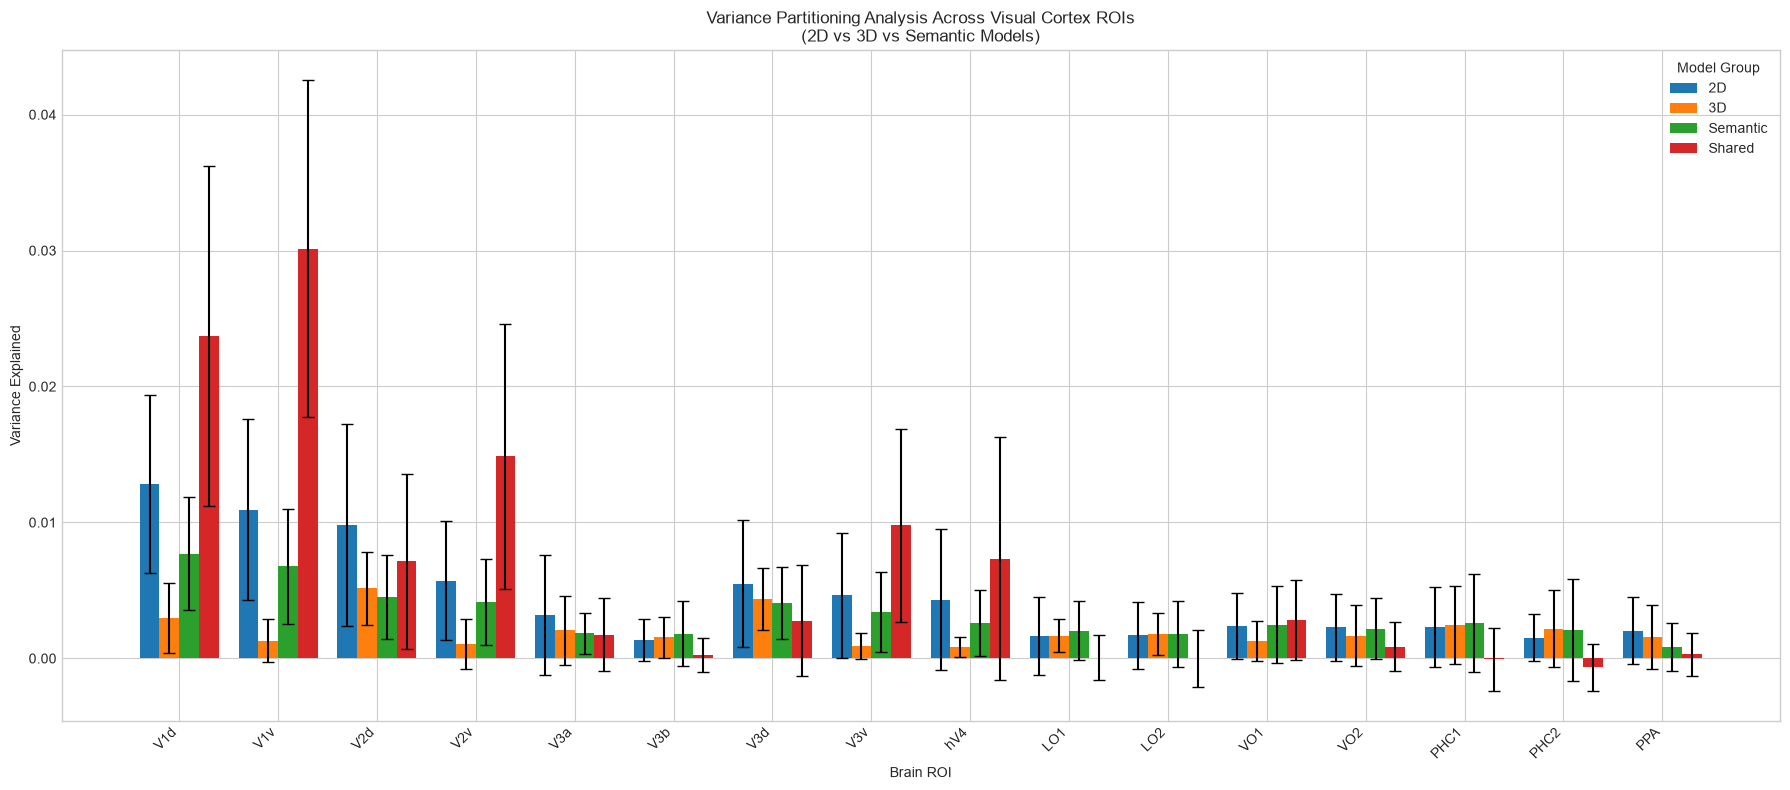

In [73]:
import matplotlib.pyplot as plt
import numpy as np

name_map = {
    "y1": "2D",
    "y2": "3D",
    "y3": "Semantic",
    "y123": "Shared"
}

df_plot["Component"] = df_plot["Variable"].map(name_map)

rois = list(df_plot["ROI"].unique())

components = [
    "2D",
    "3D",
    "Semantic",
    "Shared"
]

x = np.arange(len(rois))
width = 0.20

fig, ax = plt.subplots(figsize=(18, 8))

for i, comp in enumerate(components):

    subset = df_plot[df_plot["Component"] == comp]

    means = []
    stds = []

    for roi in rois:

        row = subset[subset["ROI"] == roi].iloc[0]

        means.append(row["Mean"])
        stds.append(row["Std"])

    ax.bar(
        x + (i - 1.5) * width,
        means,
        width,
        label=comp,
        yerr=stds,
        capsize=4
    )

ax.set_xticks(x)
ax.set_xticklabels(
    rois,
    rotation=45,
    ha="right"
)

ax.set_ylabel("Variance Explained")
ax.set_xlabel("Brain ROI")

ax.set_title(
    "Variance Partitioning Analysis Across Visual Cortex ROIs\n"
    "(2D vs 3D vs Semantic Models)"
)

ax.legend(
    title="Model Group",
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "UVP_all_ROIs_STD.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
df_vpa_all.to_csv(
    "UVP_all_ROIs.csv",
    index=False
)

print("Saved: UVP_all_ROIs.csv")

Saved: UVP_all_ROIs.csv
